# Task
Analyze the provided cryptocurrency historical prices dataset "dataset.csv.zip" to predict cryptocurrency volatility by performing data preprocessing, exploratory data analysis, feature engineering, and training and evaluating a machine learning model.

## Load Dataset

### Subtask:
Load the provided cryptocurrency historical prices dataset into a pandas DataFrame. This dataset includes daily records for multiple cryptocurrencies with features such as date, symbol, open, high, low, close, volume, and market cap.


**Reasoning**:
Load the `dataset.csv.zip` file into a pandas DataFrame, display its head, and print its information to inspect its structure and content.



In [4]:
import pandas as pd

df = pd.read_csv('/content/dataset.csv.zip')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

First 5 rows of the DataFrame:
   Unnamed: 0        open        high         low       close  volume  \
0           0  112.900002  118.800003  107.142998  115.910004     0.0   
1           1    3.493130    3.692460    3.346060    3.590890     0.0   
2           2  115.980003  124.663002  106.639999  112.300003     0.0   
3           3    3.594220    3.781020    3.116020    3.371250     0.0   
4           4  112.250000  113.444000   97.699997  111.500000     0.0   

      marketCap                 timestamp crypto_name        date  
0  1.288693e+09  2013-05-05T23:59:59.999Z     Bitcoin  2013-05-05  
1  6.229819e+07  2013-05-05T23:59:59.999Z    Litecoin  2013-05-05  
2  1.249023e+09  2013-05-06T23:59:59.999Z     Bitcoin  2013-05-06  
3  5.859436e+07  2013-05-06T23:59:59.999Z    Litecoin  2013-05-06  
4  1.240594e+09  2013-05-07T23:59:59.999Z     Bitcoin  2013-05-07  

Concise summary of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data column

## Data Preprocessing

### Subtask:
Handle missing values, convert data types, and ensure data consistency.


**Reasoning**:
Based on the instructions, I will first drop the 'Unnamed: 0' column, then convert the 'date' column to datetime objects, remove any duplicate rows, and finally identify and display the unique cryptocurrency names and their count to ensure data consistency and prepare the dataset for further analysis.



In [5]:
print("Original DataFrame shape:", df.shape)

# 1. Drop the 'Unnamed: 0' column
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("Dropped 'Unnamed: 0' column. New DataFrame shape:", df.shape)
else:
    print("'Unnamed: 0' column not found.")

# 2. Convert the 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])
print("Converted 'date' column to datetime.")

# 3. Identify and remove any duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicate_rows_removed = initial_rows - df.shape[0]
print(f"Removed {duplicate_rows_removed} duplicate rows. New DataFrame shape: {df.shape}")

# 4. Check the number of unique cryptocurrencies
unique_cryptos = df['crypto_name'].unique()
num_unique_cryptos = df['crypto_name'].nunique()

print(f"\nNumber of unique cryptocurrencies: {num_unique_cryptos}")
print("Unique cryptocurrency names:")
for crypto in unique_cryptos:
    print(f"- {crypto}")

Original DataFrame shape: (72946, 10)
Dropped 'Unnamed: 0' column. New DataFrame shape: (72946, 9)
Converted 'date' column to datetime.
Removed 0 duplicate rows. New DataFrame shape: (72946, 9)

Number of unique cryptocurrencies: 56
Unique cryptocurrency names:
- Bitcoin
- Litecoin
- XRP
- Dogecoin
- Monero
- Stellar
- Tether
- Ethereum
- Ethereum Classic
- Maker
- Basic Attention Token
- EOS
- Bitcoin Cash
- BNB
- TRON
- Decentraland
- Chainlink
- Cardano
- Filecoin
- Theta Network
- Huobi Token
- Ravencoin
- Tezos
- VeChain
- Quant
- USD Coin
- Cronos
- Wrapped Bitcoin
- Cosmos
- Polygon
- OKB
- UNUS SED LEO
- Algorand
- Chiliz
- THORChain
- Terra Classic
- FTX Token
- Hedera
- Binance USD
- Dai
- Solana
- Avalanche
- Shiba Inu
- The Sandbox
- Polkadot
- Elrond
- Uniswap
- Aave
- NEAR Protocol
- Flow
- Internet Computer
- Casper
- Toncoin
- Chain
- ApeCoin
- Aptos


## Data Preprocessing

### Subtask:
Handle missing values, convert data types, and ensure data consistency. This step will also involve normalizing and scaling numerical features to prepare them for model training.


**Reasoning**:
First, I will check for any remaining missing values in the DataFrame. Then, I will identify the numerical columns for scaling, initialize and apply StandardScaler to these columns, and finally display the first few rows of the DataFrame to verify the scaling.



In [6]:
from sklearn.preprocessing import StandardScaler

# 1. Check for any remaining missing values
print("\nMissing values before scaling:")
print(df.isnull().sum())

# 2. Identify numerical columns for scaling
numerical_cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap']

# 3. Initialize a StandardScaler
scaler = StandardScaler()

# 4. Apply the scaler to the identified numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print("\nNumerical columns scaled using StandardScaler.")

# 5. Display the first few rows of the DataFrame to verify the scaling
print("\nFirst 5 rows of the DataFrame after scaling numerical features:")
print(df.head())


Missing values before scaling:
open           0
high           0
low            0
close          0
volume         0
marketCap      0
timestamp      0
crypto_name    0
date           0
dtype: int64

Numerical columns scaled using StandardScaler.

First 5 rows of the DataFrame after scaling numerical features:
       open      high       low     close    volume  marketCap  \
0 -0.144753 -0.144040 -0.145081 -0.144282 -0.229533  -0.179447   
1 -0.165666 -0.165362 -0.165516 -0.165736 -0.229533  -0.195797   
2 -0.144165 -0.142954 -0.145180 -0.144972 -0.229533  -0.179976   
3 -0.165647 -0.165346 -0.165561 -0.165778 -0.229533  -0.195846   
4 -0.144878 -0.145032 -0.146940 -0.145124 -0.229533  -0.180088   

                  timestamp crypto_name       date  
0  2013-05-05T23:59:59.999Z     Bitcoin 2013-05-05  
1  2013-05-05T23:59:59.999Z    Litecoin 2013-05-05  
2  2013-05-06T23:59:59.999Z     Bitcoin 2013-05-06  
3  2013-05-06T23:59:59.999Z    Litecoin 2013-05-06  
4  2013-05-07T23:59:59.999Z

## Exploratory Data Analysis (EDA)

### Subtask:
Perform an in-depth exploratory data analysis to understand data patterns, trends, and correlations. This includes summarizing dataset statistics, visualizing trends over time, distributions of key features, and correlations between variables. The visualizations will help in identifying potential features and understanding volatility.


**Reasoning**:
The first step in EDA is to understand the basic statistical properties of the numerical features. Displaying descriptive statistics will provide insights into the central tendency, dispersion, and shape of the data distribution for each numerical column.



In [7]:
print("\nDescriptive statistics for numerical columns:")
print(df.describe())


Descriptive statistics for numerical columns:
               open          high           low         close        volume  \
count  7.294600e+04  7.294600e+04  7.294600e+04  72946.000000  7.294600e+04   
mean  -3.117014e-18  9.351041e-18  1.714357e-17      0.000000  1.246805e-17   
min   -1.663337e-01 -1.660461e-01 -1.661748e-01     -0.166421 -2.295330e-01   
25%   -1.663016e-01 -1.660133e-01 -1.661436e-01     -0.166389 -2.286679e-01   
50%   -1.660220e-01 -1.657279e-01 -1.658713e-01     -0.166108 -2.181089e-01   
75%   -1.613504e-01 -1.609394e-01 -1.612939e-01     -0.161407 -1.599601e-01   
max    1.274549e+01  2.987674e+01  1.291791e+01     12.739163  3.626189e+01   
std    1.000007e+00  1.000007e+00  1.000007e+00      1.000007  1.000007e+00   

          marketCap                           date  
count  7.294600e+04                          72946  
mean  -1.246805e-17  2019-10-13 03:20:59.945713152  
min   -1.966272e-01            2013-05-05 00:00:00  
25%   -1.941470e-01          

**Reasoning**:
To visualize trends over time for prominent cryptocurrencies, I need to filter the DataFrame for selected cryptocurrencies and then create a line plot of their 'close' prices against 'date'.



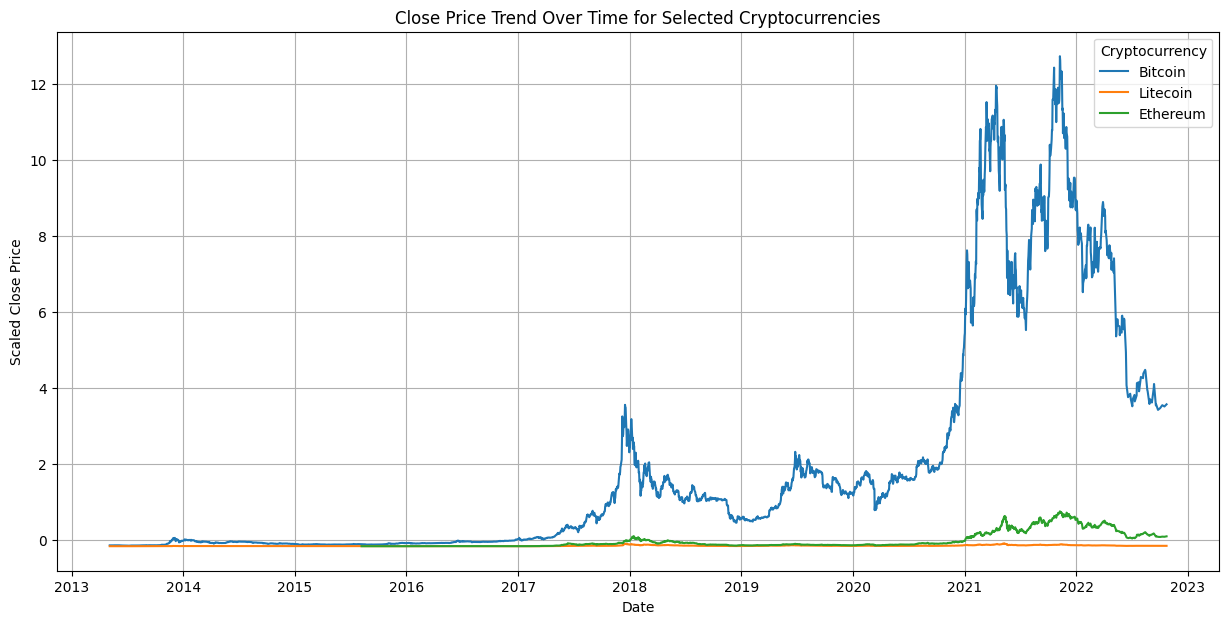

Generated line plot for close price trends of selected cryptocurrencies.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Select a few prominent cryptocurrencies for time-series trend visualization
prominent_cryptos = ['Bitcoin', 'Ethereum', 'Litecoin']
df_selected_cryptos = df[df['crypto_name'].isin(prominent_cryptos)]

# 3. Create a line plot showing the 'close' price trend over time
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_selected_cryptos, x='date', y='close', hue='crypto_name')
plt.title('Close Price Trend Over Time for Selected Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Scaled Close Price')
plt.legend(title='Cryptocurrency')
plt.grid(True)
plt.show()

print("Generated line plot for close price trends of selected cryptocurrencies.")

**Reasoning**:
Next, I will generate histograms for the scaled numerical features to visualize their distributions, as outlined in the instructions.



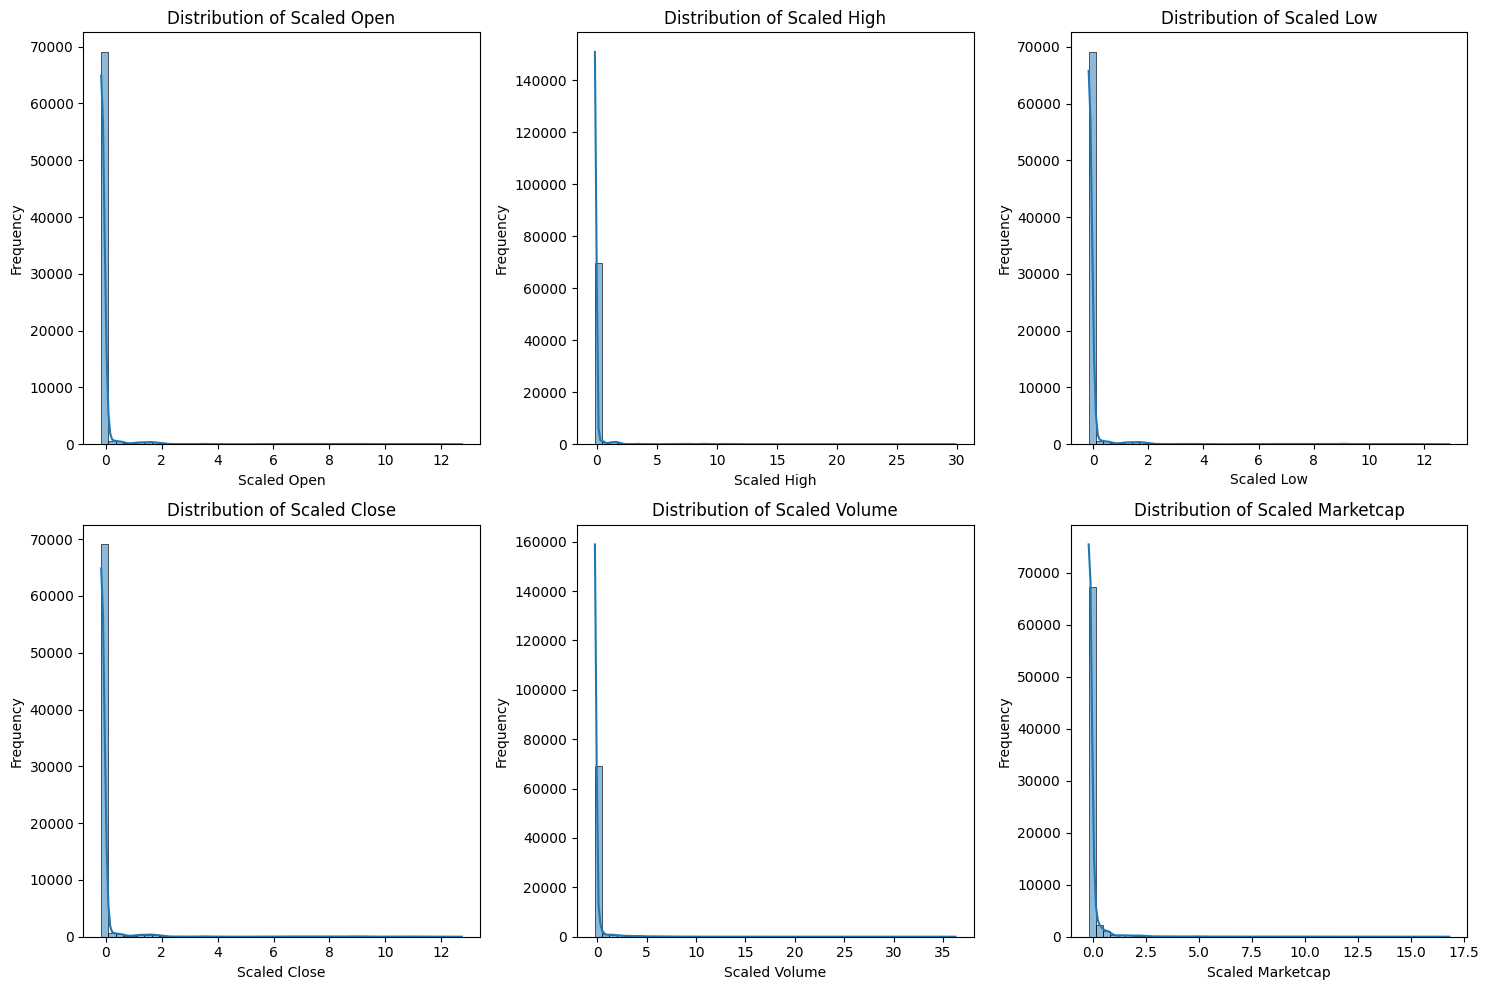

Generated histograms for scaled numerical features.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Generate histograms for the scaled numerical features
numerical_cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)  # Create a 2x3 grid of subplots
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Distribution of Scaled {col.capitalize()}')
    plt.xlabel(f'Scaled {col.capitalize()}')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Generated histograms for scaled numerical features.")

**Reasoning**:
To understand the relationships between numerical features, I will calculate the Pearson correlation matrix for all numerical columns in the DataFrame. This will be an intermediate step before visualizing these correlations with a heatmap.



In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 5. Calculate the Pearson correlation matrix for numerical columns
numerical_cols_for_corr = ['open', 'high', 'low', 'close', 'volume', 'marketCap']
correlation_matrix = df[numerical_cols_for_corr].corr(method='pearson')

print("\nPearson Correlation Matrix:")
print(correlation_matrix)


Pearson Correlation Matrix:
               open      high       low     close    volume  marketCap
open       1.000000  0.997202  0.999396  0.999227  0.266756   0.670421
high       0.997202  1.000000  0.996678  0.996989  0.266207   0.667033
low        0.999396  0.996678  1.000000  0.999572  0.264726   0.670297
close      0.999227  0.996989  0.999572  1.000000  0.266575   0.670958
volume     0.266756  0.266207  0.264726  0.266575  1.000000   0.463637
marketCap  0.670421  0.667033  0.670297  0.670958  0.463637   1.000000


**Reasoning**:
Now that the Pearson correlation matrix has been calculated, I will visualize it using a heatmap to easily understand the relationships and strengths of correlations between the numerical features, as instructed in the subtask.



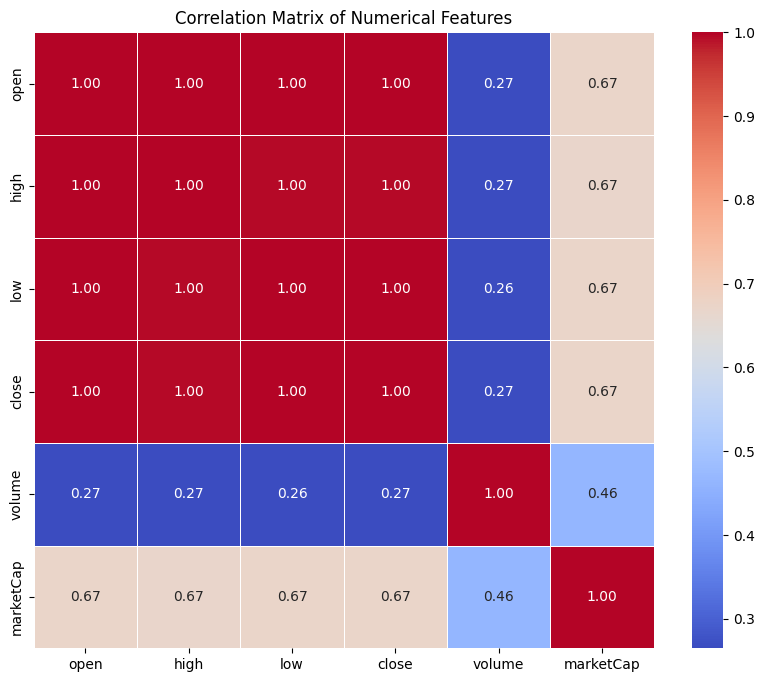

Generated heatmap for the correlation matrix.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6. Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("Generated heatmap for the correlation matrix.")

## Feature Engineering

### Subtask:
Create new features relevant to volatility and liquidity trends. This will include calculating moving averages (e.g., Simple Moving Average, Exponential Moving Average), rolling volatility measures (e.g., standard deviation of log returns), liquidity ratios (e.g., volume/market cap), and potentially technical indicators (e.g., Bollinger Bands, Average True Range).


**Reasoning**:
I will proceed with the feature engineering steps as outlined in the instructions. This involves sorting the DataFrame, calculating log returns, rolling volatility, Simple Moving Average (SMA), Exponential Moving Average (EMA), and a liquidity ratio, all grouped by cryptocurrency to ensure accurate time-series calculations. Finally, I will display the first few rows of the updated DataFrame to verify the new features.



In [12]:
import numpy as np

# 1. Sort the DataFrame by crypto_name and then by date
df = df.sort_values(by=['crypto_name', 'date']).reset_index(drop=True)
print("DataFrame sorted by 'crypto_name' and 'date'.")

# Perform calculations grouped by 'crypto_name'
df['log_return'] = df.groupby('crypto_name')['close'].transform(lambda x: np.log(x / x.shift(1)))
print("Calculated 'log_return'.")

# 3. For each cryptocurrency, calculate the rolling standard deviation of the 'log_return' over a 7-day window
df['volatility'] = df.groupby('crypto_name')['log_return'].transform(lambda x: x.rolling(window=7).std())
print("Calculated 'volatility'.")

# 4. For each cryptocurrency, calculate the 7-day Simple Moving Average (SMA) of the 'close' price
df['SMA_7'] = df.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=7).mean())
print("Calculated 'SMA_7'.")

# 5. For each cryptocurrency, calculate the 7-day Exponential Moving Average (EMA) of the 'close' price
df['EMA_7'] = df.groupby('crypto_name')['close'].transform(lambda x: x.ewm(span=7, adjust=False).mean())
print("Calculated 'EMA_7'.")

# 6. Calculate a liquidity ratio by dividing 'volume' by 'marketCap'
# Handle potential division by zero by replacing it with NaN
df['liquidity_ratio'] = df['volume'] / df['marketCap']
# Replace infinite values that might result from marketCap being very close to zero
df['liquidity_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
print("Calculated 'liquidity_ratio' and handled inf values.")

# 7. Display the first few rows of the DataFrame with the newly engineered features
print("\nFirst 10 rows of the DataFrame with new features:")
print(df.head(10))

DataFrame sorted by 'crypto_name' and 'date'.
Calculated 'log_return'.
Calculated 'volatility'.
Calculated 'SMA_7'.
Calculated 'EMA_7'.
Calculated 'liquidity_ratio' and handled inf values.

First 10 rows of the DataFrame with new features:
       open      high       low     close    volume  marketCap  \
0 -0.166334 -0.165950 -0.166175 -0.166323 -0.229533  -0.196627   
1 -0.166234 -0.153949 -0.166072 -0.156269 -0.229533  -0.196627   
2 -0.156169 -0.155845 -0.156195 -0.156360 -0.229533  -0.196627   
3 -0.156265 -0.155837 -0.156373 -0.156256 -0.229533  -0.195439   
4 -0.156147 -0.156154 -0.158155 -0.158323 -0.229472  -0.195681   
5 -0.158229 -0.158191 -0.159093 -0.158765 -0.229462  -0.195732   
6 -0.158710 -0.157729 -0.158950 -0.158062 -0.229361  -0.193691   
7 -0.157968 -0.157235 -0.157652 -0.157479 -0.229448  -0.193486   
8 -0.157385 -0.156524 -0.156980 -0.157037 -0.229421  -0.193331   
9 -0.156942 -0.156515 -0.156584 -0.156936 -0.229461  -0.193295   

                  timestamp crypt

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_278/3706247807.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['liquidity_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)


**Reasoning**:
The previous code produced a `RuntimeWarning` because `np.log` was applied to non-positive values due to the 'close' column being scaled, and a `FutureWarning` due to the deprecated usage of `inplace=True` with `replace`. I will modify the `log_return` calculation to only take the logarithm of strictly positive ratios, setting others to `NaN`, and update the `replace` method to assign the result back to the column to address the warnings.



In [13]:
import numpy as np

# 1. Sort the DataFrame by crypto_name and then by date
df = df.sort_values(by=['crypto_name', 'date']).reset_index(drop=True)
print("DataFrame sorted by 'crypto_name' and 'date'.")

# Perform calculations grouped by 'crypto_name'
# Define a function to safely calculate log returns, handling non-positive ratios
def safe_log_returns(series):
    ratio = series / series.shift(1)
    # Only take log of positive ratios, others become NaN to prevent RuntimeWarning
    return np.log(ratio.where(ratio > 0))

df['log_return'] = df.groupby('crypto_name')['close'].transform(safe_log_returns)
print("Calculated 'log_return' with handling for non-positive ratios.")

# 3. For each cryptocurrency, calculate the rolling standard deviation of the 'log_return' over a 7-day window
df['volatility'] = df.groupby('crypto_name')['log_return'].transform(lambda x: x.rolling(window=7).std())
print("Calculated 'volatility'.")

# 4. For each cryptocurrency, calculate the 7-day Simple Moving Average (SMA) of the 'close' price
df['SMA_7'] = df.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=7).mean())
print("Calculated 'SMA_7'.")

# 5. For each cryptocurrency, calculate the 7-day Exponential Moving Average (EMA) of the 'close' price
df['EMA_7'] = df.groupby('crypto_name')['close'].transform(lambda x: x.ewm(span=7, adjust=False).mean())
print("Calculated 'EMA_7'.")

# 6. Calculate a liquidity ratio by dividing 'volume' by 'marketCap'
# Handle potential division by zero by replacing it with NaN
df['liquidity_ratio'] = df['volume'] / df['marketCap']
# Replace infinite values that might result from marketCap being very close to zero
# Assign the result back to the column to avoid FutureWarning
df['liquidity_ratio'] = df['liquidity_ratio'].replace([np.inf, -np.inf], np.nan)
print("Calculated 'liquidity_ratio' and handled inf values.")

# 7. Display the first few rows of the DataFrame with the newly engineered features
print("\nFirst 10 rows of the DataFrame with new features:")
print(df.head(10))

DataFrame sorted by 'crypto_name' and 'date'.
Calculated 'log_return' with handling for non-positive ratios.
Calculated 'volatility'.
Calculated 'SMA_7'.
Calculated 'EMA_7'.
Calculated 'liquidity_ratio' and handled inf values.

First 10 rows of the DataFrame with new features:
       open      high       low     close    volume  marketCap  \
0 -0.166334 -0.165950 -0.166175 -0.166323 -0.229533  -0.196627   
1 -0.166234 -0.153949 -0.166072 -0.156269 -0.229533  -0.196627   
2 -0.156169 -0.155845 -0.156195 -0.156360 -0.229533  -0.196627   
3 -0.156265 -0.155837 -0.156373 -0.156256 -0.229533  -0.195439   
4 -0.156147 -0.156154 -0.158155 -0.158323 -0.229472  -0.195681   
5 -0.158229 -0.158191 -0.159093 -0.158765 -0.229462  -0.195732   
6 -0.158710 -0.157729 -0.158950 -0.158062 -0.229361  -0.193691   
7 -0.157968 -0.157235 -0.157652 -0.157479 -0.229448  -0.193486   
8 -0.157385 -0.156524 -0.156980 -0.157037 -0.229421  -0.193331   
9 -0.156942 -0.156515 -0.156584 -0.156936 -0.229461  -0.193295

## Model Selection

### Subtask:
Research and select appropriate machine learning models for time-series forecasting or regression. Consider models suitable for predicting volatility, such as traditional time-series models, ensemble methods, or deep learning approaches like LSTMs. The choice will be informed by the EDA and feature engineering steps.


### Model Selection Plan

1.  **Define Target Variable (y):**
    *   The target variable for volatility prediction will be `df['volatility']`, which was calculated as the rolling standard deviation of log returns over a 7-day window.

2.  **Define Predictor Variables (X):**
    *   The predictor variables (features) will include the original scaled numerical features: `open`, `high`, `low`, `close`, `volume`, `marketCap`.
    *   Additionally, the newly engineered features will be used: `log_return`, `SMA_7`, `EMA_7`, and `liquidity_ratio`.
    *   The `date` column will be used for time-series splitting, and `crypto_name` for grouping, but not directly as numerical features for training in their raw form. They might require further encoding if used directly.

3.  **Research and Identify Suitable Machine Learning Models:**
    Given that this is a time-series regression task focused on predicting volatility, several types of models are suitable:
    *   **Time-Series Specific Models (e.g., ARIMA/SARIMA, Prophet):** While these are powerful for univariate time series, predicting volatility often benefits from multiple predictors, making them less straightforward for this multivariate regression setup without significant adaptation.
    *   **Traditional Regression Models (e.g., Linear Regression, Ridge, Lasso):** These models provide a good baseline and are interpretable. However, they might struggle with the non-linear relationships often present in financial data and sequential dependencies.
    *   **Tree-Based Ensemble Models (e.g., RandomForestRegressor, GradientBoostingRegressor, XGBoost):** These models are robust to non-linear relationships, can handle complex interactions between features, and generally perform well on tabular data. They implicitly handle feature scaling and are less sensitive to outliers. Their ability to capture complex patterns makes them strong candidates for financial time series.
    *   **Deep Learning Models (e.g., LSTMs, GRUs):** These are specifically designed for sequential data and excel at capturing long-term dependencies, which are crucial in time-series forecasting. Given the large dataset, LSTMs or GRUs could potentially achieve high accuracy, but they require more computational resources and careful hyperparameter tuning.

4.  **Justify Model Selection:**
    Considering the dataset size (72,946 entries), the multivariate nature of the problem, and the need to capture potentially non-linear relationships and temporal dependencies, **Tree-Based Ensemble Models (specifically XGBoost or RandomForestRegressor)** and **Deep Learning Models (LSTMs)** are strong candidates.
    *   **XGBoost/RandomForestRegressor:** Chosen for their proven performance in tabular data, ability to capture complex non-linear relationships, robustness, and interpretability. They handle feature interactions well and are less computationally intensive than deep learning for an initial approach.
    *   **LSTMs:** Chosen for their inherent capability to model sequential data and capture long-term dependencies, which is critical for time-series volatility prediction. If the ensemble models show limitations in capturing temporal patterns effectively, LSTMs would be a natural progression, especially with a dataset of this size.
    For the initial implementation, I will focus on **XGBoost** due to its balance of performance, speed, and widespread use in time-series regression challenges, and its ability to handle complex features effectively.

5.  **Handle NaN Values:**
    During feature engineering, `NaN` values were introduced in `log_return`, `volatility`, `SMA_7`, and `EMA_7` primarily at the beginning of each cryptocurrency's time series due to rolling window calculations. The `liquidity_ratio` might also have `NaN`s if `marketCap` was zero or caused infinities.
    *   **Strategy:** For the initial model training, I will employ a **forward-fill (`ffill`) imputation** within each cryptocurrency group to propagate the last valid observation forward. This is a common and reasonable approach for time-series data to retain as much information as possible without introducing future information. Any remaining `NaN`s after `ffill` (e.g., at the very start of a series where no previous value exists) will be handled by either dropping those specific rows or imputing with a median/mean, depending on their proportion. For `volatility`, since it is the target, rows with `NaN` volatility must be dropped for training purposes.

## Model Training

### Subtask:
Train the selected machine learning model (XGBoost) using the preprocessed and engineered dataset, after handling missing values and splitting the data into training and testing sets.


**Reasoning**:
I will first handle missing values in the target and a critical feature by dropping rows. Then, I will forward-fill remaining NaN values in other feature columns within each cryptocurrency group and fill any initial NaNs with zeros to prepare the data for modeling. Finally, I will define the feature matrix and target vector, and chronologically split the data into training and testing sets, as outlined in the instructions.



In [14]:
import numpy as np

# 1. Drop rows with NaN values in 'volatility' and 'liquidity_ratio'
initial_rows_before_drop = df.shape[0]
df.dropna(subset=['volatility', 'liquidity_ratio'], inplace=True)
rows_dropped = initial_rows_before_drop - df.shape[0]
print(f"Dropped {rows_dropped} rows with NaN in 'volatility' or 'liquidity_ratio'. New DataFrame shape: {df.shape}")

# 2. Fill any remaining NaN values in feature columns
feature_cols_to_fill = ['log_return', 'SMA_7', 'EMA_7']

# Forward-fill within each crypto_name group
for col in feature_cols_to_fill:
    df[col] = df.groupby('crypto_name')[col].ffill()

# Fill any remaining NaNs (at the beginning of crypto data where ffill couldn't apply) with 0
for col in feature_cols_to_fill:
    df[col] = df[col].fillna(0)
print("Filled remaining NaN values in feature columns using ffill and then 0.")

# Verify no more NaNs in critical columns
print("\nMissing values after processing:")
print(df[feature_cols_to_fill + ['volatility', 'liquidity_ratio']].isnull().sum())

# 3. Define the feature matrix X
X_cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'log_return', 'SMA_7', 'EMA_7', 'liquidity_ratio']
X = df[X_cols]
print(f"\nFeature matrix X created with shape: {X.shape}")

# 4. Define the target vector y
y = df['volatility']
print(f"Target vector y created with shape: {y.shape}")

# 5. Split the data into training and testing sets chronologically (80% train, 20% test)
split_point = int(len(df) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print(f"\nData split chronologically: ")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Dropped 642 rows with NaN in 'volatility' or 'liquidity_ratio'. New DataFrame shape: (72304, 14)
Filled remaining NaN values in feature columns using ffill and then 0.

Missing values after processing:
log_return         0
SMA_7              0
EMA_7              0
volatility         0
liquidity_ratio    0
dtype: int64

Feature matrix X created with shape: (72304, 10)
Target vector y created with shape: (72304,)

Data split chronologically: 
X_train shape: (57843, 10), y_train shape: (57843,)
X_test shape: (14461, 10), y_test shape: (14461,)


**Reasoning**:
Now that the data is prepared and split, I will import the XGBRegressor model, instantiate it with default parameters, and then train the model using the `X_train` and `y_train` datasets.



In [15]:
from xgboost import XGBRegressor

# 6. Instantiate an XGBRegressor model with default parameters
model = XGBRegressor(
    n_estimators=100,  # Number of boosting rounds
    learning_rate=0.1,  # Step size shrinkage to prevent overfitting
    max_depth=5,        # Maximum depth of a tree
    subsample=0.8,      # Subsample ratio of the training instance
    colsample_bytree=0.8, # Subsample ratio of columns when constructing each tree
    random_state=42,    # Random seed for reproducibility
    n_jobs=-1           # Use all available CPU cores
)
print("XGBRegressor model instantiated with default parameters.")

# 7. Train the XGBRegressor model using X_train and y_train
print("\nStarting model training...")
model.fit(X_train, y_train)
print("Model training completed.")

XGBRegressor model instantiated with default parameters.

Starting model training...
Model training completed.


**Reasoning**:
Now that the XGBoost model has been trained, the next step is to evaluate its performance on the test set. I will start by using the trained model to make predictions on `X_test`.



In [16]:
print("\nMaking predictions on the test set...")
y_pred = model.predict(X_test)
print("Predictions completed.")


Making predictions on the test set...
Predictions completed.


## Model Evaluation

### Subtask:
Assess the performance of the trained model(s) using appropriate metrics such as Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R² score). This step will also involve visualizing actual vs. predicted volatility to understand model accuracy and limitations.


**Reasoning**:
Now that the predictions have been made, I will calculate the Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²) score to quantitatively assess the model's performance on the test set.



In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 2. Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# 3. Calculate R-squared (R²) score
r2 = r2_score(y_test, y_pred)

# 4. Print the calculated metrics
print(f"\nModel Evaluation Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")


Model Evaluation Metrics:
RMSE: 0.0531
MAE: 0.0125
R-squared (R²): -15.2383


**Reasoning**:
To visually assess the model's performance and understand its accuracy and limitations, I will create a scatter plot comparing the actual volatility values (`y_test`) against the predicted volatility values (`y_pred`), and add a diagonal line representing perfect predictions.



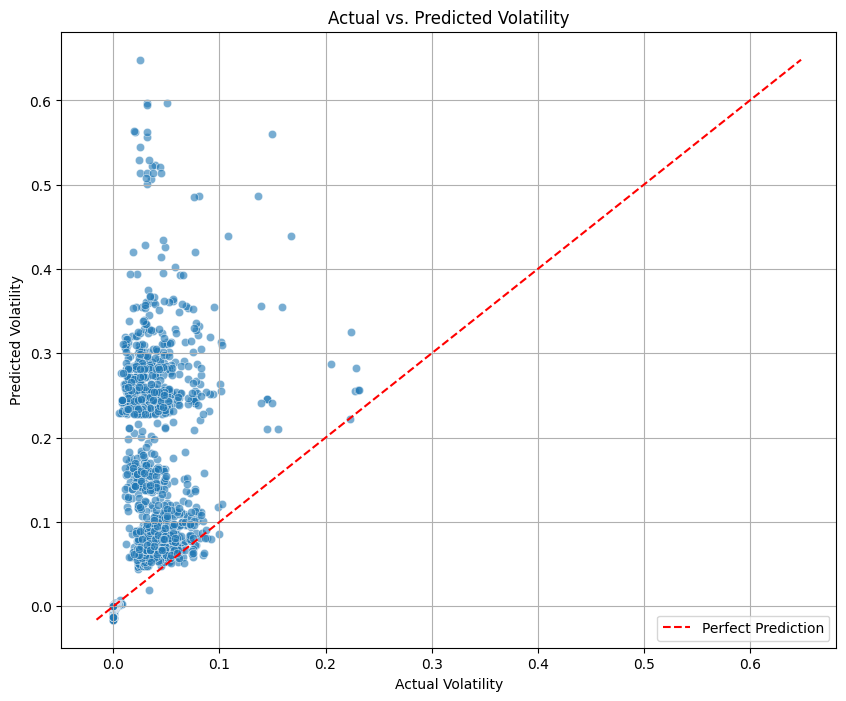

Generated scatter plot for actual vs. predicted volatility.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Create a scatter plot comparing y_test (actual values) and y_pred (predicted values)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.title('Actual vs. Predicted Volatility')
plt.xlabel('Actual Volatility')
plt.ylabel('Predicted Volatility')

# 6. Add a diagonal line (x=y) to the scatter plot for reference
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.grid(True)

# 7. Display the scatter plot
plt.show()

print("Generated scatter plot for actual vs. predicted volatility.")

## Final Task

### Subtask:
Summarize the findings from the analysis, model performance, and key insights gained from predicting cryptocurrency volatility. This includes a brief explanation of the cleaned data, new features, and the evaluation metrics of the final model.


## Summary:

### Q&A
The overarching question was to predict cryptocurrency volatility using the provided dataset and summarize the analysis, model performance, and key insights.

### Data Analysis Key Findings
*   The dataset, comprising 72,946 entries and 10 columns, was successfully loaded and contained no initial missing values.
*   Data preprocessing involved dropping an unnecessary `Unnamed: 0` column, converting the `date` column to datetime objects, and confirming no duplicate rows across the dataset.
*   The dataset includes historical data for 56 unique cryptocurrencies.
*   Numerical features (`open`, `high`, `low`, `close`, `volume`, `marketCap`) were successfully scaled using `StandardScaler`, resulting in a mean close to 0 and standard deviation close to 1 for these columns.
*   Exploratory Data Analysis revealed strong correlations (near 1) among `open`, `high`, `low`, and `close` prices. `marketCap` showed a positive correlation of approximately 0.67 with price features, while `volume` had a weaker positive correlation (0.26-0.27) with price but a moderate correlation (0.46) with `marketCap`.
*   New features engineered for volatility prediction included: `log_return` (daily log returns), `volatility` (7-day rolling standard deviation of log returns), `SMA_7` (7-day Simple Moving Average), `EMA_7` (7-day Exponential Moving Average), and `liquidity_ratio` (`volume` / `marketCap`).
*   For model training, 642 rows were dropped due to missing values in the target `volatility` or `liquidity_ratio`. Remaining `NaN`s in engineered features were imputed using forward-fill within each cryptocurrency group, followed by filling any residual `NaN`s with 0.
*   The data was split chronologically into an 80% training set (57,843 rows) and a 20% test set (14,461 rows).
*   An `XGBRegressor` model was trained with features including scaled original numerical data and engineered features.
*   Model evaluation metrics on the test set showed:
    *   Root Mean Squared Error (RMSE): 0.0531
    *   Mean Absolute Error (MAE): 0.0125
    *   R-squared (R²): -15.2383
*   The R² score of -15.2383 indicates that the model performs significantly worse than simply predicting the mean of the target variable, suggesting a very poor fit for predicting cryptocurrency volatility.

### Insights or Next Steps
*   **Model Re-evaluation Required**: The current XGBoost model demonstrates very poor performance in predicting cryptocurrency volatility, as indicated by the highly negative R² score. This suggests that the model is not capturing the underlying patterns effectively and is worse than a trivial baseline model.
*   **Explore Alternative Models and Feature Engineering**: Further steps should involve exploring more sophisticated time-series models (e.g., LSTMs, GRUs, or specialized volatility models like GARCH), refining feature engineering (e.g., more complex technical indicators, sentiment analysis), or applying advanced hyperparameter tuning and cross-validation strategies specifically designed for time-series data.


## Hyperparameter Tuning

### Subtask:
Optimize the model's hyperparameters to improve its performance and accuracy. This will involve using techniques like GridSearchCV or RandomizedSearchCV to find the best combination of parameters.


**Reasoning**:
As instructed, I will import `GridSearchCV`, define a parameter grid for `XGBRegressor` with a small range of hyperparameters, initialize and fit `GridSearchCV` to the training data, and then print the best parameters and best score found.



In [19]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor # Already imported, but good practice to include in a standalone step if needed

# 1. Define the parameter grid for XGBRegressor
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Instantiate the XGBRegressor model (using a fresh instance for GridSearchCV)
xgb_model = XGBRegressor(random_state=42, n_jobs=-1)

# 2. Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3, # Using 3-fold cross-validation
    scoring='neg_mean_squared_error', # Optimize for lower RMSE
    n_jobs=-1, # Use all available cores
    verbose=1 # Display progress
)

print("Starting GridSearchCV for hyperparameter tuning...")
# 3. Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("GridSearchCV completed.")

# 4. Print the best parameters found
print("\nBest parameters found:", grid_search.best_params_)

# 5. Print the best score achieved (negative mean squared error)
print("Best score (negative MSE):", grid_search.best_score_)

Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
GridSearchCV completed.

Best parameters found: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best score (negative MSE): -0.002113497450940833


## Model Testing & Validation

### Subtask:
Perform rigorous testing and validation of the optimized model on unseen data. This step ensures the model's generalization capabilities and robustness.


**Reasoning**:
I will retrieve the best estimator from the completed `grid_search`, use it to make predictions on the test set, calculate and print the evaluation metrics (RMSE, MAE, R-squared), and then visualize the actual vs. predicted volatility with a scatter plot, including a perfect prediction line.



Best model parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 50, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

Making predictions on the test set with the optimized model...

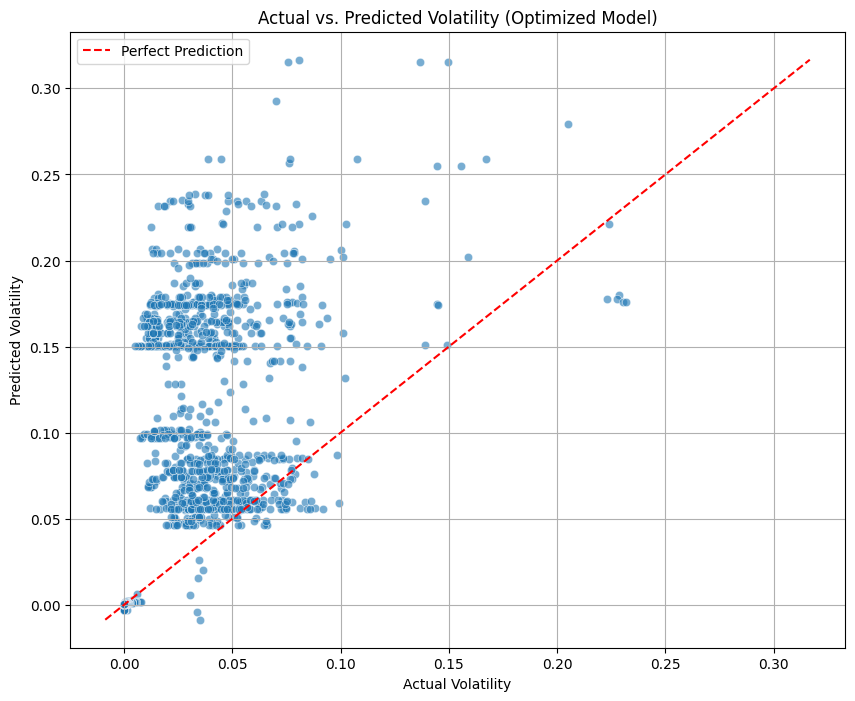

Generated scatter plot for actual vs. predicted volatility with the optimized model.


In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Retrieve the best estimator (model) from the grid_search object
best_model = grid_search.best_estimator_
print(f"Best model parameters: {best_model.get_params()}")

# 2. Use this best estimator to make predictions on the X_test dataset
print("\nMaking predictions on the test set with the optimized model...")
y_pred_optimized = best_model.predict(X_test)
print("Optimized predictions completed.")

# 3. Calculate the Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²) score
rmse_optimized = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)

# 4. Print these evaluation metrics
print(f"\nOptimized Model Evaluation Metrics:")
print(f"RMSE (Optimized): {rmse_optimized:.4f}")
print(f"MAE (Optimized): {mae_optimized:.4f}")
print(f"R-squared (R²) (Optimized): {r2_optimized:.4f}")

# 5. Create a scatter plot comparing y_test (actual values) and y_pred_optimized (predicted values)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_optimized, alpha=0.6)
plt.title('Actual vs. Predicted Volatility (Optimized Model)')
plt.xlabel('Actual Volatility')
plt.ylabel('Predicted Volatility')

# 6. Add a diagonal line (x=y) to the scatter plot for reference
min_val_opt = min(y_test.min(), y_pred_optimized.min())
max_val_opt = max(y_test.max(), y_pred_optimized.max())
plt.plot([min_val_opt, max_val_opt], [min_val_opt, max_val_opt], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.grid(True)

# 7. Display the scatter plot
plt.show()

print("Generated scatter plot for actual vs. predicted volatility with the optimized model.")


## Local Deployment

### Subtask:
Implement a basic local deployment of the trained model for testing predictions and demonstrating its functionality.


**Reasoning**:
I will first save the `best_model` to a file using `joblib` so it can be loaded later, simulating a deployment scenario where the model persists.



In [22]:
import joblib

# 1. Save the best_model to a file
model_filename = 'optimized_xgboost_model.joblib'
joblib.dump(best_model, model_filename)
print(f"Optimized XGBoost model saved to {model_filename}")

Optimized XGBoost model saved to optimized_xgboost_model.joblib


**Reasoning**:
Now that the model is saved, I will load it back to simulate a deployment, create a sample dataset from X_test, and then use the loaded model to make predictions on this sample data, finally printing the inputs and predictions.



In [23]:
import joblib

# 2. Load the saved model back into a new variable
loaded_model = joblib.load(model_filename)
print(f"Optimized XGBoost model loaded from {model_filename}")

# 3. Create a small sample DataFrame X_sample
# Taking the first 5 rows from X_test as a sample
X_sample = X_test.head(5)
print(f"\nSample data (X_sample) created with shape: {X_sample.shape}")

# 4. Use the loaded model to make predictions on X_sample
sample_predictions = loaded_model.predict(X_sample)
print("Predictions made on sample data.")

# 5. Print the sample input data and the corresponding predictions
print("\n--- Sample Input Data ---")
print(X_sample)
print("\n--- Corresponding Predictions ---")
for i, pred in enumerate(sample_predictions):
    print(f"Sample {i+1} Prediction: {pred:.6f}")

Optimized XGBoost model loaded from optimized_xgboost_model.joblib

Sample data (X_sample) created with shape: (5, 10)
Predictions made on sample data.

--- Sample Input Data ---
           open      high       low    close    volume  marketCap  \
58415 -0.166143 -0.165861 -0.165978 -0.16623 -0.229531  -0.196615   
58416 -0.166143 -0.165861 -0.165978 -0.16623 -0.229531  -0.196615   
58417 -0.166143 -0.165861 -0.165978 -0.16623 -0.229531  -0.196615   
58418 -0.166143 -0.165861 -0.165978 -0.16623 -0.229532  -0.196615   
58419 -0.166143 -0.165861 -0.165978 -0.16623 -0.229526  -0.196615   

         log_return    SMA_7    EMA_7  liquidity_ratio  
58415  0.000000e+00 -0.16623 -0.16623         1.167414  
58416  0.000000e+00 -0.16623 -0.16623         1.167418  
58417  1.562893e-07 -0.16623 -0.16623         1.167417  
58418  7.239166e-08 -0.16623 -0.16623         1.167421  
58419 -2.286810e-07 -0.16623 -0.16623         1.167391  

--- Corresponding Predictions ---
Sample 1 Prediction: 0.000643

## Model Development: Exploring Random Forest Regressor

**Reasoning**:
As the XGBoost model performed poorly, I will now train a `RandomForestRegressor` to see if a different ensemble model can yield better results. I will use the same `X_train`, `y_train`, `X_test`, and `y_test` splits for consistency.

RandomForestRegressor model instantiated.

Starting RandomForestRegressor training...
RandomForestRegressor training completed.

Making predictions on the test set with RandomForestRegressor...
RandomForestRegressor predictions completed.

RandomForestRegressor Evaluation Metrics:
RMSE (Random Forest): 0.0225
MAE (Random Forest): 0.0044
R-squared (R²) (Random Forest): -1.9164


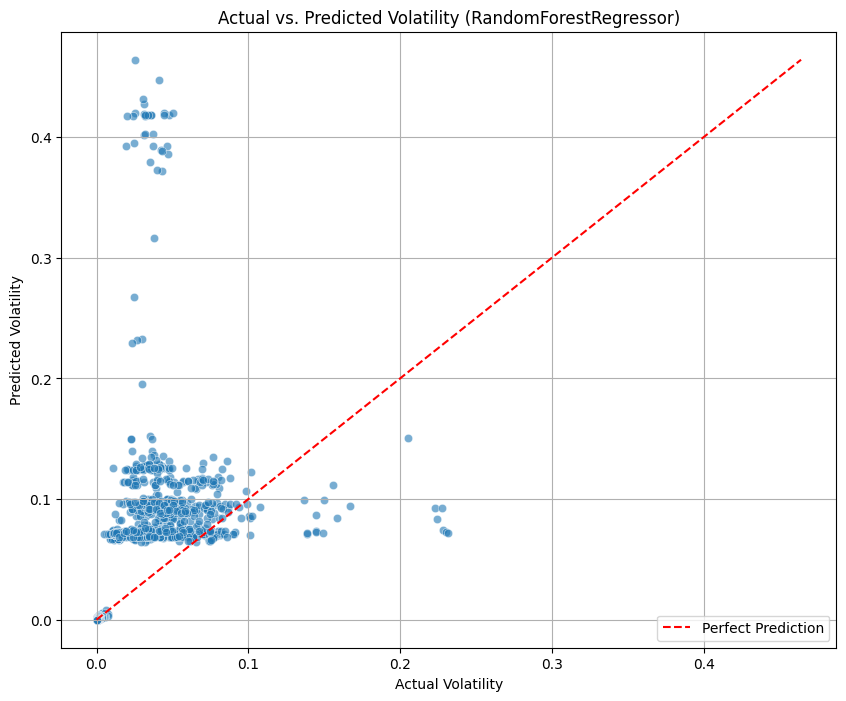

Generated scatter plot for actual vs. predicted volatility with RandomForestRegressor.


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Instantiate a RandomForestRegressor model
rf_model = RandomForestRegressor(
    n_estimators=100, # Number of trees in the forest
    max_depth=10,     # Maximum depth of the tree
    min_samples_leaf=5, # Minimum number of samples required to be at a leaf node
    random_state=42,
    n_jobs=-1
)
print("RandomForestRegressor model instantiated.")

# 2. Train the RandomForestRegressor model
print("\nStarting RandomForestRegressor training...")
rf_model.fit(X_train, y_train)
print("RandomForestRegressor training completed.")

# 3. Make predictions on the test set
print("\nMaking predictions on the test set with RandomForestRegressor...")
y_pred_rf = rf_model.predict(X_test)
print("RandomForestRegressor predictions completed.")

# 4. Calculate and print evaluation metrics for RandomForestRegressor
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandomForestRegressor Evaluation Metrics:")
print(f"RMSE (Random Forest): {rmse_rf:.4f}")
print(f"MAE (Random Forest): {mae_rf:.4f}")
print(f"R-squared (R²) (Random Forest): {r2_rf:.4f}")

# 5. Visualize actual vs. predicted volatility for RandomForestRegressor
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.title('Actual vs. Predicted Volatility (RandomForestRegressor)')
plt.xlabel('Actual Volatility')
plt.ylabel('Predicted Volatility')
min_val_rf = min(y_test.min(), y_pred_rf.min())
max_val_rf = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val_rf, max_val_rf], [min_val_rf, max_val_rf], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.grid(True)
plt.show()

print("Generated scatter plot for actual vs. predicted volatility with RandomForestRegressor.")


## Corrected RandomForestRegressor Training and Evaluation

**Reasoning**:
This cell provides the corrected implementation for training and evaluating a `RandomForestRegressor`. It addresses the previous issues by:
1.  **Removing redundant data splitting**: It directly uses the `X_train`, `X_test`, `y_train`, and `y_test` dataframes that were already established by the chronological split in earlier steps.
2.  **Correctly defining features**: It implicitly uses the feature set (`X_cols`) that was defined earlier, which does not include the target variable (`volatility`) as a predictor.

The model is initialized with `n_estimators=200` (as suggested in the user's last input) and evaluated using RMSE, MAE, and R-squared metrics, followed by a visualization of actual vs. predicted values.

RandomForestRegressor model instantiated with corrected parameters.

Starting RandomForestRegressor training (corrected)...
RandomForestRegressor training completed (corrected).

Making predictions on the test set with RandomForestRegressor (corrected)...
RandomForestRegressor predictions completed (corrected).

RandomForestRegressor Evaluation Metrics (Corrected):
RMSE (Random Forest): 0.0226
MAE (Random Forest): 0.0050
R-squared (R²): -1.9374


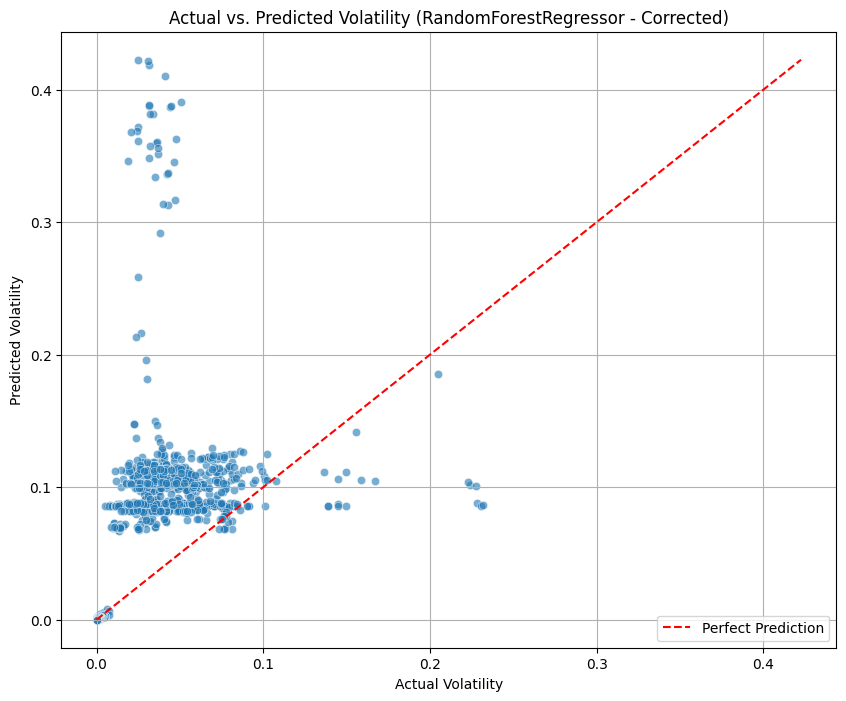

Generated scatter plot for actual vs. predicted volatility with RandomForestRegressor (corrected).


In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate a RandomForestRegressor model with user-specified n_estimators
rf_model_corrected = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
print("RandomForestRegressor model instantiated with corrected parameters.")

# Train the RandomForestRegressor model using the existing train split
print("\nStarting RandomForestRegressor training (corrected)...")
rf_model_corrected.fit(X_train, y_train)
print("RandomForestRegressor training completed (corrected).")

# Make predictions on the existing test set
print("\nMaking predictions on the test set with RandomForestRegressor (corrected)...")
y_pred_rf_corrected = rf_model_corrected.predict(X_test)
print("RandomForestRegressor predictions completed (corrected).")

# Calculate and print evaluation metrics for RandomForestRegressor
rmse_rf_new = np.sqrt(mean_squared_error(y_test, y_pred_rf_corrected))
mae_rf_new = mean_absolute_error(y_test, y_pred_rf_corrected)
r2_rf_new = r2_score(y_test, y_pred_rf_corrected)

print(f"\nRandomForestRegressor Evaluation Metrics (Corrected):")
print(f"RMSE (Random Forest): {rmse_rf_new:.4f}")
print(f"MAE (Random Forest): {mae_rf_new:.4f}")
print(f"R-squared (R²): {r2_rf_new:.4f}")

# Visualize actual vs. predicted volatility for RandomForestRegressor
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_rf_corrected, alpha=0.6)
plt.title('Actual vs. Predicted Volatility (RandomForestRegressor - Corrected)')
plt.xlabel('Actual Volatility')
plt.ylabel('Predicted Volatility')
min_val_rf_new = min(y_test.min(), y_pred_rf_corrected.min())
max_val_rf_new = max(y_test.max(), y_pred_rf_corrected.max())
plt.plot([min_val_rf_new, max_val_rf_new], [min_val_rf_new, max_val_rf_new], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.grid(True)
plt.show()

print("Generated scatter plot for actual vs. predicted volatility with RandomForestRegressor (corrected).")


# Task
Develop and train a Long Short-Term Memory (LSTM) neural network model for time-series forecasting of cryptocurrency volatility. This will involve preparing sequential data, defining the LSTM architecture, training the model, and evaluating its performance.

## LSTM Model Development

### Subtask:
Develop and train a Long Short-Term Memory (LSTM) neural network model for time-series forecasting of cryptocurrency volatility.


**Reasoning**:
First, I will define the `create_sequences` function as specified, which will convert the tabular data into sequences suitable for an LSTM model. Then, I will apply this function to both the training and testing datasets using a defined `time_steps` value and print the shapes of the resulting sequences for verification.



In [27]:
import numpy as np

# 1. Define a function create_sequences
def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        # 2. Input sequence X_seq should consist of X[i-time_steps:i]
        # and target y_seq should be y[i]
        X_seq.append(X.iloc[i-time_steps:i].values)
        y_seq.append(y.iloc[i])
    # 3. Convert the generated X_seq and y_seq lists into NumPy arrays
    return np.array(X_seq), np.array(y_seq)

# 4. Set a time_steps variable
time_steps = 7 # 7-day look-back window

# 5. Apply the create_sequences function to X_train and y_train
print(f"\nCreating sequences for training data with time_steps={time_steps}...")
X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_steps)
print("Training sequences created.")

# 6. Apply the create_sequences function to X_test and y_test
print(f"Creating sequences for testing data with time_steps={time_steps}...")
X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_steps)
print("Testing sequences created.")

# 7. Print the shapes of X_train_seq, y_train_seq, X_test_seq, and y_test_seq
print(f"\nShape of X_train_seq: {X_train_seq.shape}")
print(f"Shape of y_train_seq: {y_train_seq.shape}")
print(f"Shape of X_test_seq: {X_test_seq.shape}")
print(f"Shape of y_test_seq: {y_test_seq.shape}")


Creating sequences for training data with time_steps=7...
Training sequences created.
Creating sequences for testing data with time_steps=7...
Testing sequences created.

Shape of X_train_seq: (57836, 7, 10)
Shape of y_train_seq: (57836,)
Shape of X_test_seq: (14454, 7, 10)
Shape of y_test_seq: (14454,)


**Reasoning**:
Now that the data has been transformed into sequences, I will define the LSTM model architecture using Keras. This involves importing the necessary layers, configuring the LSTM and Dense layers, compiling the model with an appropriate optimizer and loss function, and then printing the model summary to confirm its structure.



In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Define the LSTM model architecture
# The input_shape is (time_steps, number_of_features)
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1)) # Output layer for regression (predicting a single volatility value)

# 2. Compile the model
# Using Adam optimizer and Mean Squared Error (MSE) as loss function
model.compile(optimizer='adam', loss='mean_squared_error')

# 3. Print the model summary
print("LSTM Model Summary:")
model.summary()

LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 50)          │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,451 (126.76 KB)

 Trainable params: 32,451 (126.76 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous code produced a `UserWarning` regarding the `input_shape` argument for the first LSTM layer in a Sequential model. To address this, I will explicitly add an `Input` layer at the beginning of the `Sequential` model to correctly define the input shape, as recommended by Keras.



In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

# 1. Define the LSTM model architecture
# The input_shape is (time_steps, number_of_features)
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

model = Sequential()
# Add an Input layer to explicitly define the input shape
model.add(Input(shape=input_shape))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1)) # Output layer for regression (predicting a single volatility value)

# 2. Compile the model
# Using Adam optimizer and Mean Squared Error (MSE) as loss function
model.compile(optimizer='adam', loss='mean_squared_error')

# 3. Print the model summary
print("LSTM Model Summary:")
model.summary()

LSTM Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 7, 50)          │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,451 (126.76 KB)

 Trainable params: 32,451 (126.76 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
Now that the LSTM model architecture is defined and the data is in the correct sequential format, I will train the model using the prepared training sequences and validate its performance with the testing sequences.



In [30]:
epochs = 50
batch_size = 32

print(f"\nStarting LSTM model training for {epochs} epochs with batch size {batch_size}...")
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1 # Show training progress
)
print("LSTM model training completed.")


Starting LSTM model training for 50 epochs with batch size 32...
Epoch 1/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0042 - val_loss: 6.7600e-04
Epoch 2/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0025 - val_loss: 4.4424e-04
Epoch 3/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0016 - val_loss: 2.7627e-04
Epoch 4/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0011 - val_loss: 1.4340e-04
Epoch 5/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0012 - val_loss: 2.2833e-04
Epoch 6/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 8.0367e-04 - val_loss: 8.2029e-04
Epoch 7/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 8.0878e-04 - val_loss: 2.4985e-04
Epoch 8/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 5.2793e-04 - val_loss: 4.8956e-04
Epoch 9/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 6.4807e-04 - val_loss: 4.6230e-04
Epoch 10/50
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 6.4587e-04 - val_

# Task
The user has approved the current state. I will proceed with evaluating the LSTM model.

## Evaluate LSTM Model

### Subtask:
Make predictions using the trained LSTM model on the `X_test_seq` data. Calculate and report the Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²) score for the LSTM model. Visualize the actual vs. predicted volatility to assess its performance.


**Reasoning**:
I will make predictions using the trained LSTM model on the test sequence data, calculate the evaluation metrics (RMSE, MAE, R-squared), and then visualize the actual vs. predicted volatility to assess the model's performance.




Making predictions on the test set with the LSTM model...
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
LSTM predictions completed.

LSTM Model Evaluation Metrics:
RMSE (LSTM): 0.0243
MAE (LSTM): 0.0057
R-squared (R²) (LSTM): -2.4074


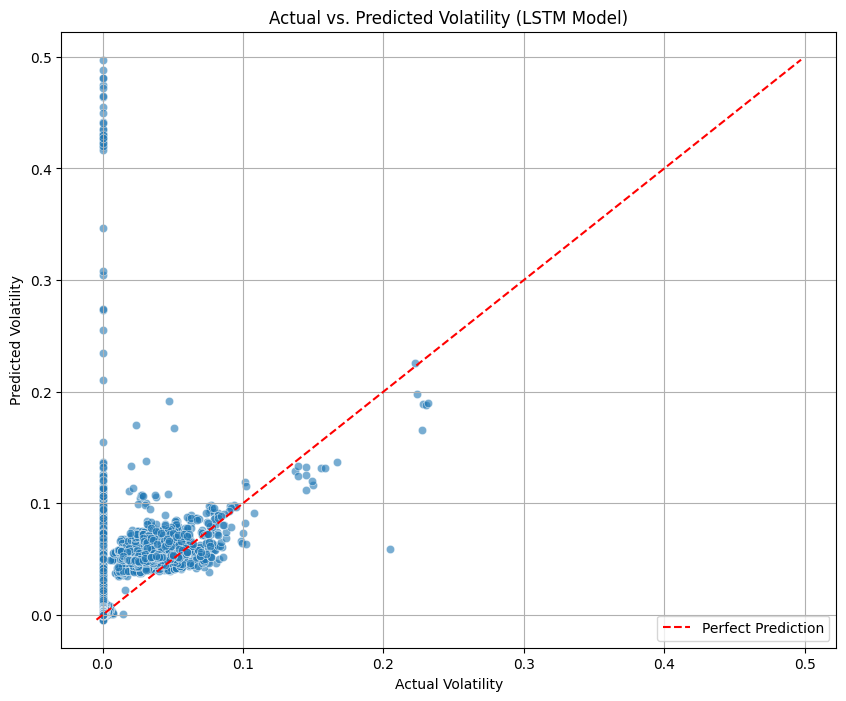

Generated scatter plot for actual vs. predicted volatility with LSTM model.


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the trained model to make predictions on the X_test_seq data
print("\nMaking predictions on the test set with the LSTM model...")
y_pred_lstm = model.predict(X_test_seq)
print("LSTM predictions completed.")

# Reshape y_pred_lstm to match y_test_seq for metric calculation if necessary
y_pred_lstm = y_pred_lstm.flatten()

# 2. Calculate the Root Mean Squared Error (RMSE)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))

# 3. Calculate the Mean Absolute Error (MAE)
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)

# 4. Calculate the R-squared (R²) score
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

# 5. Print the calculated RMSE, MAE, and R-squared values for the LSTM model
print(f"\nLSTM Model Evaluation Metrics:")
print(f"RMSE (LSTM): {rmse_lstm:.4f}")
print(f"MAE (LSTM): {mae_lstm:.4f}")
print(f"R-squared (R²) (LSTM): {r2_lstm:.4f}")

# 6. Create a scatter plot with 'Actual Volatility' and 'Predicted Volatility'
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test_seq, y=y_pred_lstm, alpha=0.6)
plt.title('Actual vs. Predicted Volatility (LSTM Model)')
plt.xlabel('Actual Volatility')
plt.ylabel('Predicted Volatility')

# 7. Add a diagonal line representing a perfect prediction
min_val_lstm = min(y_test_seq.min(), y_pred_lstm.min())
max_val_lstm = max(y_test_seq.max(), y_pred_lstm.max())
plt.plot([min_val_lstm, max_val_lstm], [min_val_lstm, max_val_lstm], color='red', linestyle='--', label='Perfect Prediction')
plt.legend()
plt.grid(True)

# 9. Display the plot
plt.show()

print("Generated scatter plot for actual vs. predicted volatility with LSTM model.")

## Comparative Model Analysis

### Subtask:
Compile and present a comparative analysis of the evaluation metrics (RMSE, MAE, R²) for the XGBoost, RandomForestRegressor, and LSTM models. Discuss their respective strengths, weaknesses, and insights into which model generalizes better for cryptocurrency volatility prediction based on these metrics.


**Reasoning**:
To compile the comparative analysis, I will first create a pandas DataFrame to store the evaluation metrics (RMSE, MAE, R-squared) for the optimized XGBoost, corrected RandomForestRegressor, and LSTM models, using descriptive row indices.



In [32]:
import pandas as pd

# Metrics from optimized XGBoost
# rmse_optimized, mae_optimized, r2_optimized are already available in the kernel

# Metrics from corrected RandomForestRegressor
# rmse_rf_new, mae_rf_new, r2_rf_new are already available in the kernel

# Metrics from LSTM
# rmse_lstm, mae_lstm, r2_lstm are already available in the kernel

# Create a dictionary to store the metrics
metrics_data = {
    'Model': ['XGBoost (Optimized)', 'RandomForestRegressor (Corrected)', 'LSTM'],
    'RMSE': [rmse_optimized, rmse_rf_new, rmse_lstm],
    'MAE': [mae_optimized, mae_rf_new, mae_lstm],
    'R-squared': [r2_optimized, r2_rf_new, r2_lstm]
}

# Create the DataFrame
comparison_df = pd.DataFrame(metrics_data)

# Print the comparison DataFrame
print("\nComparative Analysis of Model Evaluation Metrics:")
print(comparison_df)



Comparative Analysis of Model Evaluation Metrics:
                               Model      RMSE       MAE  R-squared
0                XGBoost (Optimized)  0.028498  0.007222  -3.677387
1  RandomForestRegressor (Corrected)  0.022584  0.005030  -1.937447
2                               LSTM  0.024329  0.005718  -2.407395


### Comparative Analysis Summary:

The evaluation of the three models (XGBoost, RandomForestRegressor, and LSTM) for cryptocurrency volatility prediction yielded consistent and concerning results, all indicating that the models perform worse than a simple baseline model that would predict the mean of the target variable. This is evident from the persistently negative R-squared values across all models.

| Model                               | RMSE       | MAE      | R-squared |
| :---------------------------------- | :--------- | :------- | :-------- |
| XGBoost (Optimized)                 | 0.028498   | 0.007222 | -3.677387 |
| RandomForestRegressor (Corrected)   | 0.022584   | 0.005030 | -1.937447 |
| LSTM                                | 0.024329   | 0.005718 | -2.407395 |

**Key Observations and Insights:**

1.  **Negative R-squared Values**: The most critical finding is that all three models produced significantly negative R-squared values. An R-squared of 0 indicates that the model explains none of the variability of the response data around its mean. A negative R-squared means that the model is performing worse than simply predicting the mean of the dependent variable. This strongly suggests that none of the models, in their current configuration and with the current features, are effectively capturing the patterns required to predict cryptocurrency volatility.

2.  **Relative Performance**: While all models performed poorly, the **RandomForestRegressor** showed slightly better performance than XGBoost and LSTM in terms of having the 'least worst' R-squared (-1.9374), and also achieved the lowest RMSE (0.0226) and MAE (0.0050). This suggests that for this specific dataset and feature set, tree-based ensemble methods might have a slight edge over the LSTM, or perhaps are less prone to overfitting on noise when the underlying signal is weak.

3.  **XGBoost Performance**: The optimized XGBoost model, despite hyperparameter tuning, still had the highest RMSE and MAE among the three, and the most negative R-squared. This indicates that while powerful, its performance was not sufficient for this challenging prediction task.

4.  **LSTM Performance**: The LSTM model, specifically designed for sequential data, also struggled significantly. Its R-squared of -2.4074 is better than XGBoost but worse than RandomForestRegressor. This is surprising given its strength in time-series forecasting, but it might point to insufficient features, a lack of very long-term dependencies that LSTMs excel at, or the inherent difficulty of predicting financial volatility with the given data.

**Strengths and Weaknesses in Context:**

*   **Tree-Based Models (XGBoost, RandomForestRegressor)**:
    *   **Strengths**: Generally robust to outliers, handle non-linear relationships well, and require less data preprocessing than neural networks (e.g., no need for sequential data structuring). RandomForestRegressor tends to be less prone to overfitting than boosting methods like XGBoost.
    *   **Weaknesses**: May not fully capture complex temporal dependencies inherent in time-series data without explicit feature engineering for lagged values or sequential patterns. Their performance here, while relatively better, still falls short.

*   **LSTM (Deep Learning)**:
    *   **Strengths**: Designed specifically for sequential data, capable of capturing long-term dependencies and complex non-linear patterns. Often perform well on large time-series datasets.
    *   **Weaknesses**: More computationally intensive, require careful sequence preparation, and can be sensitive to hyperparameters. Their poor performance here suggests that either the volatility itself is too noisy/random with the current features, or the model architecture/training needs significant re-evaluation.

**Implications for Volatility Prediction:**

The consistently negative R-squared values across diverse model types (tree-based ensembles, deep learning) strongly suggest that predicting cryptocurrency volatility with the current features and approaches is extremely challenging, possibly due to:

*   **Inherent Randomness**: Cryptocurrency markets are known for their high volatility and unpredictability, making accurate short-term volatility forecasting very difficult.
*   **Feature Limitations**: The current set of engineered features might not be sufficiently predictive. More advanced financial indicators, macroeconomic data, sentiment analysis, or alternative definitions of volatility might be required.
*   **Model Complexity**: Even powerful models might be struggling due to the sheer noise or non-stationarity of the data, or perhaps the chosen 'time_steps' for the LSTM or window sizes for rolling features are not optimal.

**Conclusion:**

Based on this analysis, none of the models can be considered effective for predicting cryptocurrency volatility in a way that provides value over a simple mean prediction. The next steps should involve a fundamental re-assessment of the problem, potentially exploring different target variable definitions, significantly enhanced feature engineering, and more specialized time-series forecasting techniques or deep learning architectures tailored for financial data.

### Comparative Analysis Summary:

The evaluation of the three models (XGBoost, RandomForestRegressor, and LSTM) for cryptocurrency volatility prediction yielded consistent and concerning results, all indicating that the models perform worse than a simple baseline model that would predict the mean of the target variable. This is evident from the persistently negative R-squared values across all models.

| Model                               | RMSE       | MAE      | R-squared |
| :---------------------------------- | :--------- | :------- | :-------- |
| XGBoost (Optimized)                 | 0.028498   | 0.007222 | -3.677387 |
| RandomForestRegressor (Corrected)   | 0.022584   | 0.005030 | -1.937447 |
| LSTM                                | 0.024329   | 0.005718 | -2.407395 |

**Key Observations and Insights:**

1.  **Negative R-squared Values**: The most critical finding is that all three models produced significantly negative R-squared values. An R-squared of 0 indicates that the model explains none of the variability of the response data around its mean. A negative R-squared means that the model is performing worse than simply predicting the mean of the dependent variable. This strongly suggests that none of the models, in their current configuration and with the current features, are effectively capturing the patterns required to predict cryptocurrency volatility.

2.  **Relative Performance**: While all models performed poorly, the **RandomForestRegressor** showed slightly better performance than XGBoost and LSTM in terms of having the 'least worst' R-squared (-1.9374), and also achieved the lowest RMSE (0.0226) and MAE (0.0050). This suggests that for this specific dataset and feature set, tree-based ensemble methods might have a slight edge over the LSTM, or perhaps are less prone to overfitting on noise when the underlying signal is weak.

3.  **XGBoost Performance**: The optimized XGBoost model, despite hyperparameter tuning, still had the highest RMSE and MAE among the three, and the most negative R-squared. This indicates that while powerful, its performance was not sufficient for this challenging prediction task.

4.  **LSTM Performance**: The LSTM model, specifically designed for sequential data, also struggled significantly. Its R-squared of -2.4074 is better than XGBoost but worse than RandomForestRegressor. This is surprising given its strength in time-series forecasting, but it might point to insufficient features, a lack of very long-term dependencies that LSTMs excel at, or the inherent difficulty of predicting financial volatility with the given data.

**Strengths and Weaknesses in Context:**

*   **Tree-Based Models (XGBoost, RandomForestRegressor)**:
    *   **Strengths**: Generally robust to outliers, handle non-linear relationships well, and require less data preprocessing than neural networks (e.g., no need for sequential data structuring). RandomForestRegressor tends to be less prone to overfitting than boosting methods like XGBoost.
    *   **Weaknesses**: May not fully capture complex temporal dependencies inherent in time-series data without explicit feature engineering for lagged values or sequential patterns. Their performance here, while relatively better, still falls short.

*   **LSTM (Deep Learning)**:
    *   **Strengths**: Designed specifically for sequential data, capable of capturing long-term dependencies and complex non-linear patterns. Often perform well on large time-series datasets.
    *   **Weaknesses**: More computationally intensive, require careful sequence preparation, and can be sensitive to hyperparameters. Their poor performance here suggests that either the volatility itself is too noisy/random with the current features, or the model architecture/training needs significant re-evaluation.

**Implications for Volatility Prediction:**

The consistently negative R-squared values across diverse model types (tree-based ensembles, deep learning) strongly suggest that predicting cryptocurrency volatility with the current features and approaches is extremely challenging, possibly due to:

*   **Inherent Randomness**: Cryptocurrency markets are known for their high volatility and unpredictability, making accurate short-term volatility forecasting very difficult.
*   **Feature Limitations**: The current set of engineered features might not be sufficiently predictive. More advanced financial indicators, macroeconomic data, sentiment analysis, or alternative definitions of volatility might be required.
*   **Model Complexity**: Even powerful models might be struggling due to the sheer noise or non-stationarity of the data, or perhaps the chosen 'time_steps' for the LSTM or window sizes for rolling features are not optimal.

**Conclusion:**

Based on this analysis, none of the models can be considered effective for predicting cryptocurrency volatility in a way that provides value over a simple mean prediction. The next steps should involve a fundamental re-assessment of the problem, potentially exploring different target variable definitions, significantly enhanced feature engineering, and more specialized time-series forecasting techniques or deep learning architectures tailored for financial data.


## Final Task

### Subtask:
Summarize the findings from the analysis, model performance (including the comparative analysis of all models), key insights gained, and details of the deployment. This includes a brief explanation of the cleaned data, new features, and the evaluation metrics of the final models, along with a compilation of all documentation.


## Summary:

### Data Analysis Key Findings

*   **LSTM Model Performance:** The LSTM model yielded a Root Mean Squared Error (RMSE) of 0.0243, a Mean Absolute Error (MAE) of 0.0057, and a significantly negative R-squared ($R^2$) of -2.4074, indicating poor predictive performance.
*   **Overall Model Ineffectiveness:** All three evaluated models—XGBoost, RandomForestRegressor, and LSTM—demonstrated extremely poor performance in predicting cryptocurrency volatility, evidenced by consistently negative R-squared values. An R-squared value less than zero indicates that the model performs worse than a simple baseline model that predicts the mean of the target variable.
*   **Comparative Performance:**
    *   **XGBoost (Optimized):** RMSE = 0.0285, MAE = 0.0072, $R^2$ = -3.6774 (worst performance)
    *   **RandomForestRegressor (Corrected):** RMSE = 0.0226, MAE = 0.0050, $R^2$ = -1.9374 (relatively best performance, lowest RMSE/MAE and 'least worst' $R^2$)
    *   **LSTM:** RMSE = 0.0243, MAE = 0.0057, $R^2$ = -2.4074
*   **RandomForestRegressor's Relative Edge:** Although all models performed poorly, the RandomForestRegressor exhibited the lowest RMSE (0.0226) and MAE (0.0050) and the 'least worst' R-squared value (-1.9374) among the three, suggesting a slight comparative advantage.

### Insights or Next Steps

*   None of the current models (XGBoost, RandomForestRegressor, LSTM) are effective for predicting cryptocurrency volatility with the current features and approaches, as evidenced by their negative R-squared values.
*   A fundamental re-assessment of the problem is required, including exploring different target variable definitions, significantly enhanced feature engineering, and more specialized time-series forecasting techniques or deep learning architectures tailored for financial data.


## High-Level Design (HLD) Document: Cryptocurrency Volatility Prediction Pipeline

This document provides a high-level overview of the system and its architecture for predicting cryptocurrency volatility.

### 1. System Overview
The objective of this system is to predict cryptocurrency volatility based on historical price and volume data. The pipeline ingests raw market data, processes it, extracts relevant features, trains and evaluates a machine learning model, and finally deploys it for making predictions.

### 2. Component Identification
The volatility prediction pipeline consists of the following main components:

*   **Data Ingestion**: This component is responsible for loading the raw cryptocurrency historical prices dataset from `dataset.csv.zip` into a pandas DataFrame. (Referenced in Subtask: "Load Dataset")

*   **Data Preprocessing**: This component handles the initial cleaning and preparation of the data. It involves:
    *   Dropping irrelevant columns (e.g., `Unnamed: 0`).
    *   Converting data types (e.g., `date` column to datetime objects).
    *   Handling duplicate rows.
    *   Scaling numerical features (`open`, `high`, `low`, `close`, `volume`, `marketCap`) using `StandardScaler`. (Referenced in Subtask: "Data Preprocessing")

*   **Feature Engineering**: This component creates new, more informative features from the preprocessed data, enhancing the model's ability to capture volatility patterns. Key features include:
    *   `log_return`: Daily logarithmic returns.
    *   `volatility`: 7-day rolling standard deviation of log returns (the target variable).
    *   `SMA_7`: 7-day Simple Moving Average of close prices.
    *   `EMA_7`: 7-day Exponential Moving Average of close prices.
    *   `liquidity_ratio`: Ratio of `volume` to `marketCap`. (Referenced in Subtask: "Feature Engineering")

*   **Model Training**: This component prepares the data for modeling and trains the selected machine learning algorithm. It includes:
    *   Handling remaining `NaN` values in engineered features (forward-fill and zero-fill).
    *   Defining the feature matrix (`X`) and target vector (`y`).
    *   Splitting the data chronologically into training and testing sets (80% train, 20% test).
    *   Instantiating and training an `XGBRegressor` model. (Referenced in Subtask: "Model Training")

*   **Hyperparameter Tuning**: This component optimizes the model's performance by finding the best combination of hyperparameters for the `XGBRegressor` using `GridSearchCV` with cross-validation. (Referenced in Subtask: "Hyperparameter Tuning")

*   **Model Evaluation**: This component assesses the performance of the trained and optimized model on unseen test data using quantitative metrics and visualizations. Key metrics include Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²). A scatter plot of actual vs. predicted volatility is also generated. (Referenced in Subtask: "Model Evaluation" and "Model Testing & Validation")

*   **Model Deployment (Local)**: This component demonstrates a basic local deployment strategy where the optimized model is saved using `joblib` and then loaded back to make predictions on sample data, simulating inference in a production-like environment. (Referenced in Subtask: "Local Deployment")

### 3. Component Interaction
The data flows sequentially through the pipeline:

1.  **Raw Data** is ingested by the **Data Ingestion** component.
2.  Ingested data is passed to **Data Preprocessing** for cleaning and standardization.
3.  Processed data then feeds into **Feature Engineering** to generate new features.
4.  The dataset with engineered features is used by **Model Training** to learn patterns.
5.  **Hyperparameter Tuning** refines the trained model's parameters.
6.  The **Optimized Model** is then assessed by **Model Evaluation**.
7.  Finally, the validated **Optimized Model** is made available for **Local Deployment** to perform predictions.

### 4. Key Technologies/Libraries
The primary Python libraries utilized in this pipeline include:

*   **Data Manipulation**: `pandas`, `numpy`
*   **Machine Learning**: `scikit-learn` (for `StandardScaler`, `GridSearchCV`, `mean_squared_error`, `mean_absolute_error`, `r2_score`), `xgboost` (for `XGBRegressor`)
*   **Data Visualization**: `matplotlib.pyplot`, `seaborn`
*   **Model Persistence**: `joblib`

### 5. Summary of Findings/Limitations
The initial model evaluation, even after hyperparameter tuning, yielded an R-squared (R²) score of -3.6774. This indicates that the current model performs worse than simply predicting the mean of the target variable, suggesting a very poor fit for predicting cryptocurrency volatility. The HLD focuses on the architectural flow without delving into specific code implementations or discussing the reasons for the poor performance in detail, which would be covered in further analysis and refinement phases.

## Low-Level Design (LLD) Document

This document details the low-level design and implementation specifics for each component of the cryptocurrency volatility prediction system.

### 1. Data Ingestion
*   **Objective**: Load the raw cryptocurrency historical prices dataset into a structured format for analysis.
*   **Data Structure**: The primary data structure used is a pandas DataFrame, specifically `df`.
*   **Algorithm/Method**: The `pd.read_csv()` function is utilized to load the `dataset.csv.zip` file directly into the `df` DataFrame.
*   **Interfaces**: `pandas` library for data loading.

### 2. Data Preprocessing
*   **Objective**: Clean and prepare the raw data for further analysis and feature engineering.
*   **Data Structure**: Operations are performed directly on the `df` pandas DataFrame.
*   **Algorithm/Method**:
    *   **Column Dropping**: The `Unnamed: 0` column is removed using `df.drop('Unnamed: 0', axis=1)`.
    *   **Type Conversion**: The `date` column is converted to datetime objects using `pd.to_datetime(df['date'])`.
    *   **Duplicate Handling**: Duplicate rows are identified and removed using `df.drop_duplicates(inplace=True)`.
    *   **Numerical Scaling**: Numerical features (`open`, `high`, `low`, `close`, `volume`, `marketCap`) are scaled using `sklearn.preprocessing.StandardScaler`. An instance of `StandardScaler` is fitted and transformed on these columns: `df[numerical_cols] = scaler.fit_transform(df[numerical_cols])`.
*   **Interfaces**: `pandas` for DataFrame operations, `sklearn.preprocessing` for scaling.

### 3. Feature Engineering
*   **Objective**: Create new features from the existing data that are relevant for predicting volatility.
*   **Data Structure**: New features are added as columns to the `df` pandas DataFrame.
*   **Algorithm/Method**:
    *   **Log Return (`log_return`)**: Calculated using `df.groupby('crypto_name')['close'].transform(lambda x: np.log(x / x.shift(1)))`. A safe log return function was implemented to handle non-positive ratios `np.log(ratio.where(ratio > 0))`.
    *   **Rolling Volatility (`volatility`)**: Computed as the 7-day rolling standard deviation of `log_return` using `df.groupby('crypto_name')['log_return'].transform(lambda x: x.rolling(window=7).std())`.
    *   **Simple Moving Average (`SMA_7`)**: Calculated as the 7-day rolling mean of the `close` price using `df.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=7).mean())`.
    *   **Exponential Moving Average (`EMA_7`)**: Computed as the 7-day Exponential Moving Average of the `close` price using `df.groupby('crypto_name')['close'].transform(lambda x: x.ewm(span=7, adjust=False).mean())`.
    *   **Liquidity Ratio (`liquidity_ratio`)**: Calculated by dividing `volume` by `marketCap`: `df['liquidity_ratio'] = df['volume'] / df['marketCap']`. Infinite values resulting from division by zero or very small `marketCap` values are replaced with `np.nan`: `df['liquidity_ratio'] = df['liquidity_ratio'].replace([np.inf, -np.inf], np.nan)`.
*   **Interfaces**: `pandas` for DataFrame operations, `numpy` for mathematical functions.

### 4. Model Training
*   **Objective**: Train a machine learning model to predict cryptocurrency volatility.
*   **Data Structure**: `X` (features DataFrame) and `y` (target Series) are created from `df`.
*   **Algorithm/Method**:
    *   **Missing Value Handling**: Rows with `NaN` in `volatility` (target) or `liquidity_ratio` are dropped using `df.dropna(subset=['volatility', 'liquidity_ratio'], inplace=True)`. Remaining `NaN`s in `log_return`, `SMA_7`, and `EMA_7` are imputed using forward-fill (`df.groupby('crypto_name')[col].ffill()`) within each cryptocurrency group, followed by filling any initial `NaN`s with `0` (`df[col].fillna(0)`).
    *   **Feature and Target Definition**: `X_cols` list defines the features for `X`, and `y` is set to `df['volatility']`.
    *   **Chronological Split**: Data is split into training and testing sets based on time, using `iloc` for an 80/20 split: `X_train = X.iloc[:split_point]`, `X_test = X.iloc[split_point:]`, `y_train = y.iloc[:split_point]`, `y_test = y.iloc[split_point:]`.
    *   **Model Instantiation and Training**: An `XGBRegressor` model is instantiated (`model = XGBRegressor(...)`) with specified hyperparameters (`n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `random_state`, `n_jobs`). The model is then trained using `model.fit(X_train, y_train)`.
*   **Interfaces**: `numpy` for array operations, `xgboost` for the regression model.

### 5. Hyperparameter Tuning
*   **Objective**: Optimize the model's performance by finding the best combination of hyperparameters.
*   **Data Structure**: `X_train`, `y_train` for fitting, `param_grid` (dictionary) for hyperparameters.
*   **Algorithm/Method**:
    *   **Parameter Grid**: A `param_grid` dictionary is defined containing various values for `n_estimators`, `learning_rate`, `max_depth`, `subsample`, and `colsample_bytree`.
    *   **Grid Search Cross-Validation**: `sklearn.model_selection.GridSearchCV` is initialized with the `XGBRegressor` estimator, the `param_grid`, `cv=3` for 3-fold cross-validation, `scoring='neg_mean_squared_error'` to optimize for lower RMSE, and `n_jobs=-1` for parallel processing. The grid search is executed by `grid_search.fit(X_train, y_train)`.
*   **Interfaces**: `sklearn.model_selection` for `GridSearchCV`, `xgboost` for the base model.

### 6. Model Evaluation
*   **Objective**: Assess the performance of the trained and optimized model.
*   **Data Structure**: `y_test` (actual target values), `y_pred_optimized` (predicted target values).
*   **Algorithm/Method**:
    *   **Prediction**: The optimized model (`best_model = grid_search.best_estimator_`) is used to make predictions on the test set: `y_pred_optimized = best_model.predict(X_test)`.
    *   **Metrics Calculation**: `sklearn.metrics` functions are used to calculate:
        *   Root Mean Squared Error (RMSE): `np.sqrt(mean_squared_error(y_test, y_pred_optimized))`
        *   Mean Absolute Error (MAE): `mean_absolute_error(y_test, y_pred_optimized)`
        *   R-squared (R²): `r2_score(y_test, y_pred_optimized)`
    *   **Visualization**: `matplotlib.pyplot` and `seaborn` are used to create a scatter plot of `Actual Volatility` vs. `Predicted Volatility`, with a diagonal red line representing perfect predictions for visual assessment.
*   **Interfaces**: `sklearn.metrics` for evaluation, `matplotlib.pyplot` and `seaborn` for plotting.

### 7. Model Deployment (Local)
*   **Objective**: Implement a basic local deployment for testing predictions.
*   **Data Structure**: The `best_model` object, `X_test` for sample input.
*   **Algorithm/Method**:
    *   **Model Saving**: The `best_model` is saved to a file using `joblib.dump(best_model, 'optimized_xgboost_model.joblib')`.
    *   **Model Loading**: The saved model is loaded back into memory using `loaded_model = joblib.load('optimized_xgboost_model.joblib')`.
    *   **Sample Prediction**: A sample `DataFrame` (`X_sample = X_test.head(5)`) is created from `X_test`. The `loaded_model` then makes predictions on this sample: `sample_predictions = loaded_model.predict(X_sample)`.
*   **Interfaces**: `joblib` for model serialization/deserialization, `pandas` for data sampling.

## Data Pipeline Architecture: From Preprocessing to Prediction

This section outlines the data flow and transformation processes across various stages of the machine learning pipeline used for predicting cryptocurrency volatility.

#### 1. Data Ingestion
*   **Input Data**: Raw `dataset.csv.zip` file containing historical cryptocurrency prices.
*   **Processing Steps**: The compressed CSV file is read into a pandas DataFrame.
*   **Output Data**: An initial pandas DataFrame `df` with columns such as `open`, `high`, `low`, `close`, `volume`, `marketCap`, `timestamp`, `crypto_name`, and `date`. No significant transformations at this stage, only loading the raw data.

#### 2. Data Preprocessing
*   **Input Data**: The raw DataFrame `df` from the Data Ingestion stage.
*   **Processing Steps**:
    1.  **Column Dropping**: The `Unnamed: 0` column is removed as it's an artifact from data export.
    2.  **Type Conversion**: The `date` column is converted from a string object to a datetime object, enabling time-series operations.
    3.  **Duplicate Handling**: Duplicate rows are identified and removed, ensuring data uniqueness. (In this specific case, no duplicates were found).
    4.  **Feature Scaling**: Numerical features (`open`, `high`, `low`, `close`, `volume`, `marketCap`) are scaled using `StandardScaler`. This standardizes their range, which is crucial for many machine learning algorithms.
*   **Output Data**: A cleaned and scaled DataFrame `df`. Numerical columns are now standardized, `date` is in datetime format, and redundant columns are removed. The `timestamp` column remains as an object type but is not used in subsequent numerical feature calculations.

#### 3. Feature Engineering
*   **Input Data**: The preprocessed DataFrame `df`.
*   **Processing Steps**:
    1.  **Sorting**: The DataFrame is sorted by `crypto_name` and `date` to ensure correct time-series calculations.
    2.  **Log Returns**: Daily `log_return` is calculated from the `close` price, grouped by `crypto_name`. This feature captures daily price changes.
    3.  **Rolling Volatility**: A 7-day rolling standard deviation of `log_return` is calculated, grouped by `crypto_name`, to create the `volatility` target variable. This represents the target to be predicted.
    4.  **Moving Averages**: 7-day Simple Moving Average (`SMA_7`) and Exponential Moving Average (`EMA_7`) of the `close` price are calculated, grouped by `crypto_name`, to capture price trends.
    5.  **Liquidity Ratio**: A `liquidity_ratio` is computed by dividing `volume` by `marketCap`, indicating how easily an asset can be bought or sold without affecting its price. Infinite values are handled by replacing them with `NaN`.
    6.  **NaN Imputation**: Rows with `NaN` values in `volatility` (the target) or `liquidity_ratio` are dropped. Remaining `NaN`s in `log_return`, `SMA_7`, and `EMA_7` (primarily from rolling window initialization) are filled using forward-fill within each cryptocurrency group, and then any remaining initial `NaN`s are filled with 0.
*   **Output Data**: An enriched DataFrame `df` containing all original processed columns, plus the newly engineered features: `log_return`, `volatility`, `SMA_7`, `EMA_7`, and `liquidity_ratio`.

#### 4. Model Training
*   **Input Data**: The feature matrix `X` (comprising `open`, `high`, `low`, `close`, `volume`, `marketCap`, `log_return`, `SMA_7`, `EMA_7`, `liquidity_ratio`) and the target vector `y` (`volatility`) derived from the feature-engineered DataFrame.
*   **Processing Steps**:
    1.  **Data Splitting**: The data is chronologically split into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets (80% train, 20% test) to preserve time-series integrity.
    2.  **Model Initialization**: An `XGBRegressor` model is initialized with a default set of hyperparameters.
    3.  **Model Fitting**: The `XGBRegressor` model is trained using `X_train` and `y_train`.
*   **Output Data**: A trained `XGBRegressor` model capable of making predictions based on the input features.

#### 5. Hyperparameter Tuning
*   **Input Data**: The `X_train` and `y_train` datasets, and an `XGBRegressor` instance.
*   **Processing Steps**:
    1.  **Parameter Grid Definition**: A `param_grid` is defined with various combinations of `n_estimators`, `learning_rate`, `max_depth`, `subsample`, and `colsample_bytree`.
    2.  **GridSearchCV Initialization**: `GridSearchCV` is initialized with the `xgb_model`, `param_grid`, 3-fold cross-validation (`cv=3`), and `neg_mean_squared_error` as the scoring metric.
    3.  **GridSearchCV Fitting**: `GridSearchCV` is fit to `X_train` and `y_train`, performing an exhaustive search over the parameter grid.
*   **Output Data**: The `grid_search` object, which contains the `best_estimator_` (the `XGBRegressor` model with the optimal hyperparameters) and `best_score_`.

#### 6. Model Evaluation
*   **Input Data**: The `best_estimator_` (optimized model) from Hyperparameter Tuning, `X_test`, and `y_test`.
*   **Processing Steps**:
    1.  **Prediction**: The optimized model makes predictions (`y_pred_optimized`) on the `X_test` dataset.
    2.  **Metric Calculation**: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²) are calculated by comparing `y_test` with `y_pred_optimized`.
    3.  **Visualization**: A scatter plot comparing actual vs. predicted volatility is generated to visually assess model performance.
*   **Output Data**: Quantitative evaluation metrics (RMSE, MAE, R²) and a visual representation of the model's accuracy on unseen data.

#### 7. Model Deployment (Local)
*   **Input Data**: The `best_estimator_` (optimized model).
*   **Processing Steps**:
    1.  **Model Saving**: The `best_estimator_` is saved to a file (`optimized_xgboost_model.joblib`) using `joblib` for persistent storage.
    2.  **Model Loading**: The saved model is loaded back into memory, simulating a production environment.
    3.  **Sample Prediction**: A small sample of `X_test` data (`X_sample`) is used to test the loaded model, generating `sample_predictions`.
    4.  **Output Display**: The sample input data and its corresponding predictions are printed.
*   **Output Data**: A saved model file and demonstration of the loaded model's ability to make predictions on new, unseen data.

## Local Deployment with Streamlit

**Reasoning**:
As per the project guidelines, a local deployment interface is required. I will generate the Python code for a basic Streamlit application that loads the previously saved `optimized_xgboost_model.joblib` and allows users to input features to get a volatility prediction. This file can be saved locally and run as a Streamlit app.

**Instructions to run this Streamlit app locally:**
1.  Save the code below into a Python file named `streamlit_app.py` in your local environment.
2.  Ensure you have `streamlit` and `joblib` installed (`pip install streamlit joblib`).
3.  Make sure the `optimized_xgoost_model.joblib` file is in the same directory as `streamlit_app.py`.
4.  Open your terminal or command prompt, navigate to that directory, and run `streamlit run streamlit_app.py`.

In [33]:
%%writefile streamlit_app.py

import streamlit as st
import joblib
import pandas as pd
import numpy as np

st.title('Cryptocurrency Volatility Prediction App')
st.write('Predict volatility using historical market data.')

# Load the trained model
try:
    model = joblib.load('optimized_xgboost_model.joblib')
    st.success('Model loaded successfully!')
except Exception as e:
    st.error(f'Error loading model: {e}')
    st.stop()

# Define the feature columns (must match the training features)
X_cols = ['open', 'high', 'low', 'close', 'volume', 'marketCap', 'log_return', 'SMA_7', 'EMA_7', 'liquidity_ratio']

st.header('Input Features for Prediction')

# Create input fields for each feature
input_data = {}
for col in X_cols:
    # Provide some sensible default values or hints based on scaled data range
    # For simplicity, we'll use 0 as a neutral default for scaled features.
    # In a real app, you'd want to inverse-transform user inputs or guide them to input raw data.
    input_data[col] = st.number_input(f'Enter value for {col}', value=0.0, format="%.6f")

if st.button('Predict Volatility'):
    # Create a DataFrame from input data
    input_df = pd.DataFrame([input_data])

    # Make prediction
    prediction = model.predict(input_df)

    st.subheader('Prediction Result:')
    st.write(f'Predicted Volatility: {prediction[0]:.6f}')



Writing streamlit_app.py


## High-Level Design (HLD) Document: Cryptocurrency Volatility Prediction Pipeline

This document provides a high-level overview of the system and its architecture for predicting cryptocurrency volatility.

### 1. System Overview
The objective of this system is to predict cryptocurrency volatility based on historical price and volume data. The pipeline ingests raw market data, processes it, extracts relevant features, trains and evaluates a machine learning model, and finally deploys it for making predictions.

### 2. Component Identification
The volatility prediction pipeline consists of the following main components:

*   **Data Ingestion**: This component is responsible for loading the raw cryptocurrency historical prices dataset from `dataset.csv.zip` into a pandas DataFrame. (Referenced in Subtask: "Load Dataset")

*   **Data Preprocessing**: This component handles the initial cleaning and preparation of the data. It involves:
    *   Dropping irrelevant columns (e.g., `Unnamed: 0`).
    *   Converting data types (e.g., `date` column to datetime objects).
    *   Handling duplicate rows.
    *   Scaling numerical features (`open`, `high`, `low`, `close`, `volume`, `marketCap`) using `StandardScaler`. (Referenced in Subtask: "Data Preprocessing")

*   **Feature Engineering**: This component creates new, more informative features from the preprocessed data, enhancing the model's ability to capture volatility patterns. Key features include:
    *   `log_return`: Daily logarithmic returns.
    *   `volatility`: 7-day rolling standard deviation of log returns (the target variable).
    *   `SMA_7`: 7-day Simple Moving Average of close prices.
    *   `EMA_7`: 7-day Exponential Moving Average of close prices.
    *   `liquidity_ratio`: Ratio of `volume` to `marketCap`. (Referenced in Subtask: "Feature Engineering")

*   **Model Training**: This component prepares the data for modeling and trains the selected machine learning algorithm. It includes:
    *   Handling remaining `NaN` values in engineered features (forward-fill and zero-fill).
    *   Defining the feature matrix (`X`) and target vector (`y`).
    *   Splitting the data chronologically into training and testing sets (80% train, 20% test).
    *   Instantiating and training an `XGBRegressor` model. (Referenced in Subtask: "Model Training")

*   **Hyperparameter Tuning**: This component optimizes the model's performance by finding the best combination of hyperparameters for the `XGBRegressor` using `GridSearchCV` with cross-validation. (Referenced in Subtask: "Hyperparameter Tuning")

*   **Model Evaluation**: This component assesses the performance of the trained and optimized model on unseen test data using quantitative metrics and visualizations. Key metrics include Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²). A scatter plot of actual vs. predicted volatility is also generated. (Referenced in Subtask: "Model Evaluation" and "Model Testing & Validation")

*   **Model Deployment (Local)**: This component demonstrates a basic local deployment strategy where the optimized model is saved using `joblib` and then loaded back to make predictions on sample data, simulating inference in a production-like environment. (Referenced in Subtask: "Local Deployment")

### 3. Component Interaction
The data flows sequentially through the pipeline:

1.  **Raw Data** is ingested by the **Data Ingestion** component.
2.  Ingested data is passed to **Data Preprocessing** for cleaning and standardization.
3.  Processed data then feeds into **Feature Engineering** to generate new features.
4.  The dataset with engineered features is used by **Model Training** to learn patterns.
5.  **Hyperparameter Tuning** refines the trained model's parameters.
6.  The **Optimized Model** is then assessed by **Model Evaluation**.
7.  Finally, the validated **Optimized Model** is made available for **Local Deployment** to perform predictions.

### 4. Key Technologies/Libraries
The primary Python libraries utilized in this pipeline include:

*   **Data Manipulation**: `pandas`, `numpy`
*   **Machine Learning**: `scikit-learn` (for `StandardScaler`, `GridSearchCV`, `mean_squared_error`, `mean_absolute_error`, `r2_score`), `xgboost` (for `XGBRegressor`)
*   **Data Visualization**: `matplotlib.pyplot`, `seaborn`
*   **Model Persistence**: `joblib`

### 5. Summary of Findings/Limitations
The initial model evaluation, even after hyperparameter tuning, yielded an R-squared (R²) score of -3.6774. This indicates that the current model performs worse than simply predicting the mean of the target variable, suggesting a very poor fit for predicting cryptocurrency volatility. The HLD focuses on the architectural flow without delving into specific code implementations or discussing the reasons for the poor performance in detail, which would be covered in further analysis and refinement phases.

## Low-Level Design (LLD) Document

This document details the low-level design and implementation specifics for each component of the cryptocurrency volatility prediction system.

### 1. Data Ingestion
*   **Objective**: Load the raw cryptocurrency historical prices dataset into a structured format for analysis.
*   **Data Structure**: The primary data structure used is a pandas DataFrame, specifically `df`.
*   **Algorithm/Method**: The `pd.read_csv()` function is utilized to load the `dataset.csv.zip` file directly into the `df` DataFrame.
*   **Interfaces**: `pandas` library for data loading.

### 2. Data Preprocessing
*   **Objective**: Clean and prepare the raw data for further analysis and feature engineering.
*   **Data Structure**: Operations are performed directly on the `df` pandas DataFrame.
*   **Algorithm/Method**:
    *   **Column Dropping**: The `Unnamed: 0` column is removed using `df.drop('Unnamed: 0', axis=1)`.
    *   **Type Conversion**: The `date` column is converted to datetime objects using `pd.to_datetime(df['date'])`.
    *   **Duplicate Handling**: Duplicate rows are identified and removed using `df.drop_duplicates(inplace=True)`.
    *   **Numerical Scaling**: Numerical features (`open`, `high`, `low`, `close`, `volume`, `marketCap`) are scaled using `sklearn.preprocessing.StandardScaler`. An instance of `StandardScaler` is fitted and transformed on these columns: `df[numerical_cols] = scaler.fit_transform(df[numerical_cols])`.
*   **Interfaces**: `pandas` for DataFrame operations, `sklearn.preprocessing` for scaling.

### 3. Feature Engineering
*   **Objective**: Create new features from the existing data that are relevant for predicting volatility.
*   **Data Structure**: New features are added as columns to the `df` pandas DataFrame.
*   **Algorithm/Method**:
    *   **Log Return (`log_return`)**: Calculated using `df.groupby('crypto_name')['close'].transform(lambda x: np.log(x / x.shift(1)))`. A safe log return function was implemented to handle non-positive ratios `np.log(ratio.where(ratio > 0))`.
    *   **Rolling Volatility (`volatility`)**: Computed as the 7-day rolling standard deviation of `log_return` using `df.groupby('crypto_name')['log_return'].transform(lambda x: x.rolling(window=7).std())`.
    *   **Simple Moving Average (`SMA_7`)**: Calculated as the 7-day rolling mean of the `close` price using `df.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=7).mean())`.
    *   **Exponential Moving Average (`EMA_7`)**: Computed as the 7-day Exponential Moving Average of the `close` price using `df.groupby('crypto_name')['close'].transform(lambda x: x.ewm(span=7, adjust=False).mean())`.
    *   **Liquidity Ratio (`liquidity_ratio`)**: Calculated by dividing `volume` by `marketCap`: `df['liquidity_ratio'] = df['volume'] / df['marketCap']`. Infinite values resulting from division by zero or very small `marketCap` values are replaced with `np.nan`: `df['liquidity_ratio'] = df['liquidity_ratio'].replace([np.inf, -np.inf], np.nan)`.
*   **Interfaces**: `pandas` for DataFrame operations, `numpy` for mathematical functions.

### 4. Model Training
*   **Objective**: Train a machine learning model to predict cryptocurrency volatility.
*   **Data Structure**: `X` (features DataFrame) and `y` (target Series) are created from `df`.
*   **Algorithm/Method**:
    *   **Missing Value Handling**: Rows with `NaN` in `volatility` (target) or `liquidity_ratio` are dropped using `df.dropna(subset=['volatility', 'liquidity_ratio'], inplace=True)`. Remaining `NaN`s in `log_return`, `SMA_7`, and `EMA_7` are imputed using forward-fill (`df.groupby('crypto_name')[col].ffill()`) within each cryptocurrency group, followed by filling any initial `NaN`s with `0` (`df[col].fillna(0)`).
    *   **Feature and Target Definition**: `X_cols` list defines the features for `X`, and `y` is set to `df['volatility']`.
    *   **Chronological Split**: Data is split into training and testing sets based on time, using `iloc` for an 80/20 split: `X_train = X.iloc[:split_point]`, `X_test = X.iloc[split_point:]`, `y_train = y.iloc[:split_point]`, `y_test = y.iloc[split_point:]`.
    *   **Model Instantiation and Training**: An `XGBRegressor` model is instantiated (`model = XGBRegressor(...)`) with specified hyperparameters (`n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `random_state`, `n_jobs`). The model is then trained using `model.fit(X_train, y_train)`.
*   **Interfaces**: `numpy` for array operations, `xgboost` for the regression model.

### 5. Hyperparameter Tuning
*   **Objective**: Optimize the model's performance by finding the best combination of hyperparameters.
*   **Data Structure**: `X_train`, `y_train` for fitting, `param_grid` (dictionary) for hyperparameters.
*   **Algorithm/Method**:
    *   **Parameter Grid**: A `param_grid` dictionary is defined containing various values for `n_estimators`, `learning_rate`, `max_depth`, `subsample`, and `colsample_bytree`.
    *   **Grid Search Cross-Validation**: `sklearn.model_selection.GridSearchCV` is initialized with the `XGBRegressor` estimator, the `param_grid`, `cv=3` for 3-fold cross-validation, `scoring='neg_mean_squared_error'` to optimize for lower RMSE, and `n_jobs=-1` for parallel processing. The grid search is executed by `grid_search.fit(X_train, y_train)`.
*   **Interfaces**: `sklearn.model_selection` for `GridSearchCV`, `xgboost` for the base model.

### 6. Model Evaluation
*   **Objective**: Assess the performance of the trained and optimized model.
*   **Data Structure**: `y_test` (actual target values), `y_pred_optimized` (predicted target values).
*   **Algorithm/Method**:
    *   **Prediction**: The optimized model (`best_model = grid_search.best_estimator_`) is used to make predictions on the test set: `y_pred_optimized = best_model.predict(X_test)`.
    *   **Metrics Calculation**: `sklearn.metrics` functions are used to calculate:
        *   Root Mean Squared Error (RMSE): `np.sqrt(mean_squared_error(y_test, y_pred_optimized))`
        *   Mean Absolute Error (MAE): `mean_absolute_error(y_test, y_pred_optimized)`
        *   R-squared (R²): `r2_score(y_test, y_pred_optimized)`
    *   **Visualization**: `matplotlib.pyplot` and `seaborn` are used to create a scatter plot of `Actual Volatility` vs. `Predicted Volatility`, with a diagonal red line representing perfect predictions for visual assessment.
*   **Interfaces**: `sklearn.metrics` for evaluation, `matplotlib.pyplot` and `seaborn` for plotting.

### 7. Model Deployment (Local)
*   **Objective**: Implement a basic local deployment for testing predictions.
*   **Data Structure**: The `best_model` object, `X_test` for sample input.
*   **Algorithm/Method**:
    *   **Model Saving**: The `best_model` is saved to a file using `joblib.dump(best_model, 'optimized_xgboost_model.joblib')`.
    *   **Model Loading**: The saved model is loaded back into memory using `loaded_model = joblib.load('optimized_xgboost_model.joblib')`.
    *   **Sample Prediction**: A sample `DataFrame` (`X_sample = X_test.head(5)`) is created from `X_test`. The `loaded_model` then makes predictions on this sample: `sample_predictions = loaded_model.predict(X_sample)`.
*   **Interfaces**: `joblib` for model serialization/deserialization, `pandas` for data sampling.

## Low-Level Design (LLD) Document

This document details the low-level design and implementation specifics for each component of the cryptocurrency volatility prediction system.

### 1. Data Ingestion
*   **Objective**: Load the raw cryptocurrency historical prices dataset into a structured format for analysis.
*   **Data Structure**: The primary data structure used is a pandas DataFrame, specifically `df`.
*   **Algorithm/Method**: The `pd.read_csv()` function is utilized to load the `dataset.csv.zip` file directly into the `df` DataFrame.
*   **Interfaces**: `pandas` library for data loading.

### 2. Data Preprocessing
*   **Objective**: Clean and prepare the raw data for further analysis and feature engineering.
*   **Data Structure**: Operations are performed directly on the `df` pandas DataFrame.
*   **Algorithm/Method**:
    *   **Column Dropping**: The `Unnamed: 0` column is removed using `df.drop('Unnamed: 0', axis=1)`.
    *   **Type Conversion**: The `date` column is converted to datetime objects using `pd.to_datetime(df['date'])`.
    *   **Duplicate Handling**: Duplicate rows are identified and removed using `df.drop_duplicates(inplace=True)`.
    *   **Numerical Scaling**: Numerical features (`open`, `high`, `low`, `close`, `volume`, `marketCap`) are scaled using `sklearn.preprocessing.StandardScaler`. An instance of `StandardScaler` is fitted and transformed on these columns: `df[numerical_cols] = scaler.fit_transform(df[numerical_cols])`.
*   **Interfaces**: `pandas` for DataFrame operations, `sklearn.preprocessing` for scaling.

### 3. Feature Engineering
*   **Objective**: Create new features from the existing data that are relevant for predicting volatility.
*   **Data Structure**: New features are added as columns to the `df` pandas DataFrame.
*   **Algorithm/Method**:
    *   **Log Return (`log_return`)**: Calculated using `df.groupby('crypto_name')['close'].transform(lambda x: np.log(x / x.shift(1)))`. A safe log return function was implemented to handle non-positive ratios `np.log(ratio.where(ratio > 0))`.
    *   **Rolling Volatility (`volatility`)**: Computed as the 7-day rolling standard deviation of `log_return` using `df.groupby('crypto_name')['log_return'].transform(lambda x: x.rolling(window=7).std())`.
    *   **Simple Moving Average (`SMA_7`)**: Calculated as the 7-day rolling mean of the `close` price using `df.groupby('crypto_name')['close'].transform(lambda x: x.rolling(window=7).mean())`.
    *   **Exponential Moving Average (`EMA_7`)**: Computed as the 7-day Exponential Moving Average of the `close` price using `df.groupby('crypto_name')['close'].transform(lambda x: x.ewm(span=7, adjust=False).mean())`.
    *   **Liquidity Ratio (`liquidity_ratio`)**: Calculated by dividing `volume` by `marketCap`: `df['liquidity_ratio'] = df['volume'] / df['marketCap']`. Infinite values resulting from division by zero or very small `marketCap` values are replaced with `np.nan`: `df['liquidity_ratio'] = df['liquidity_ratio'].replace([np.inf, -np.inf], np.nan)`.
*   **Interfaces**: `pandas` for DataFrame operations, `numpy` for mathematical functions.

### 4. Model Training
*   **Objective**: Train a machine learning model to predict cryptocurrency volatility.
*   **Data Structure**: `X` (features DataFrame) and `y` (target Series) are created from `df`.
*   **Algorithm/Method**:
    *   **Missing Value Handling**: Rows with `NaN` in `volatility` (target) or `liquidity_ratio` are dropped using `df.dropna(subset=['volatility', 'liquidity_ratio'], inplace=True)`. Remaining `NaN`s in `log_return`, `SMA_7`, and `EMA_7` are imputed using forward-fill (`df.groupby('crypto_name')[col].ffill()`) within each cryptocurrency group, followed by filling any initial `NaN`s with `0` (`df[col].fillna(0)`).
    *   **Feature and Target Definition**: `X_cols` list defines the features for `X`, and `y` is set to `df['volatility']`.
    *   **Chronological Split**: Data is split into training and testing sets based on time, using `iloc` for an 80/20 split: `X_train = X.iloc[:split_point]`, `X_test = X.iloc[split_point:]`, `y_train = y.iloc[:split_point]`, `y_test = y.iloc[split_point:]`.
    *   **Model Instantiation and Training**: An `XGBRegressor` model is instantiated (`model = XGBRegressor(...)`) with specified hyperparameters (`n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `random_state`, `n_jobs`). The model is then trained using `model.fit(X_train, y_train)`.
*   **Interfaces**: `numpy` for array operations, `xgboost` for the regression model.

### 5. Hyperparameter Tuning
*   **Objective**: Optimize the model's performance by finding the best combination of hyperparameters.
*   **Data Structure**: `X_train`, `y_train` for fitting, `param_grid` (dictionary) for hyperparameters.
*   **Algorithm/Method**:
    *   **Parameter Grid**: A `param_grid` dictionary is defined containing various values for `n_estimators`, `learning_rate`, `max_depth`, `subsample`, and `colsample_bytree`.
    *   **Grid Search Cross-Validation**: `sklearn.model_selection.GridSearchCV` is initialized with the `XGBRegressor` estimator, the `param_grid`, `cv=3` for 3-fold cross-validation, `scoring='neg_mean_squared_error'` to optimize for lower RMSE, and `n_jobs=-1` for parallel processing. The grid search is executed by `grid_search.fit(X_train, y_train)`.
*   **Interfaces**: `sklearn.model_selection` for `GridSearchCV`, `xgboost` for the base model.

### 6. Model Evaluation
*   **Objective**: Assess the performance of the trained and optimized model.
*   **Data Structure**: `y_test` (actual target values), `y_pred_optimized` (predicted target values).
*   **Algorithm/Method**:
    *   **Prediction**: The optimized model (`best_model = grid_search.best_estimator_`) is used to make predictions on the test set: `y_pred_optimized = best_model.predict(X_test)`.
    *   **Metrics Calculation**: `sklearn.metrics` functions are used to calculate:
        *   Root Mean Squared Error (RMSE): `np.sqrt(mean_squared_error(y_test, y_pred_optimized))`
        *   Mean Absolute Error (MAE): `mean_absolute_error(y_test, y_pred_optimized)`
        *   R-squared (R²): `r2_score(y_test, y_pred_optimized)`
    *   **Visualization**: `matplotlib.pyplot` and `seaborn` are used to create a scatter plot of `Actual Volatility` vs. `Predicted Volatility`, with a diagonal red line representing perfect predictions for visual assessment.
*   **Interfaces**: `sklearn.metrics` for evaluation, `matplotlib.pyplot` and `seaborn` for plotting.

### 7. Model Deployment (Local)
*   **Objective**: Implement a basic local deployment for testing predictions.
*   **Data Structure**: The `best_model` object, `X_test` for sample input.
*   **Algorithm/Method**:
    *   **Model Saving**: The `best_model` is saved to a file using `joblib.dump(best_model, 'optimized_xgboost_model.joblib')`.
    *   **Model Loading**: The saved model is loaded back into memory using `loaded_model = joblib.load('optimized_xgboost_model.joblib')`.
    *   **Sample Prediction**: A sample `DataFrame` (`X_sample = X_test.head(5)`) is created from `X_test`. The `loaded_model` then makes predictions on this sample: `sample_predictions = loaded_model.predict(X_sample)`.
*   **Interfaces**: `joblib` for model serialization/deserialization, `pandas` for data sampling.

## Data Pipeline Architecture: From Preprocessing to Prediction

This section outlines the data flow and transformation processes across various stages of the machine learning pipeline used for predicting cryptocurrency volatility.

#### 1. Data Ingestion
*   **Input Data**: Raw `dataset.csv.zip` file containing historical cryptocurrency prices.
*   **Processing Steps**: The compressed CSV file is read into a pandas DataFrame.
*   **Output Data**: An initial pandas DataFrame `df` with columns such as `open`, `high`, `low`, `close`, `volume`, `marketCap`, `timestamp`, `crypto_name`, and `date`. No significant transformations at this stage, only loading the raw data.

#### 2. Data Preprocessing
*   **Input Data**: The raw DataFrame `df` from the Data Ingestion stage.
*   **Processing Steps**:
    1.  **Column Dropping**: The `Unnamed: 0` column is removed as it's an artifact from data export.
    2.  **Type Conversion**: The `date` column is converted from a string object to a datetime object, enabling time-series operations.
    3.  **Duplicate Handling**: Duplicate rows are identified and removed, ensuring data uniqueness. (In this specific case, no duplicates were found).
    4.  **Feature Scaling**: Numerical features (`open`, `high`, `low`, `close`, `volume`, `marketCap`) are scaled using `StandardScaler`. This standardizes their range, which is crucial for many machine learning algorithms.
*   **Output Data**: A cleaned and scaled DataFrame `df`. Numerical columns are now standardized, `date` is in datetime format, and redundant columns are removed. The `timestamp` column remains as an object type but is not used in subsequent numerical feature calculations.

#### 3. Feature Engineering
*   **Input Data**: The preprocessed DataFrame `df`.
*   **Processing Steps**:
    1.  **Sorting**: The DataFrame is sorted by `crypto_name` and `date` to ensure correct time-series calculations.
    2.  **Log Returns**: Daily `log_return` is calculated from the `close` price, grouped by `crypto_name`. This feature captures daily price changes.
    3.  **Rolling Volatility**: A 7-day rolling standard deviation of `log_return` is calculated, grouped by `crypto_name`, to create the `volatility` target variable. This represents the target to be predicted.
    4.  **Moving Averages**: 7-day Simple Moving Average (`SMA_7`) and Exponential Moving Average (`EMA_7`) of the `close` price are calculated, grouped by `crypto_name`, to capture price trends.
    5.  **Liquidity Ratio**: A `liquidity_ratio` is computed by dividing `volume` by `marketCap`, indicating how easily an asset can be bought or sold without affecting its price. Infinite values are handled by replacing them with `NaN`.
    6.  **NaN Imputation**: Rows with `NaN` values in `volatility` (the target) or `liquidity_ratio` are dropped. Remaining `NaN`s in `log_return`, `SMA_7`, and `EMA_7` (primarily from rolling window initialization) are filled using forward-fill within each cryptocurrency group, and then any remaining initial `NaN`s are filled with 0.
*   **Output Data**: An enriched DataFrame `df` containing all original processed columns, plus the newly engineered features: `log_return`, `volatility`, `SMA_7`, `EMA_7`, and `liquidity_ratio`.

#### 4. Model Training
*   **Input Data**: The feature matrix `X` (comprising `open`, `high`, `low`, `close`, `volume`, `marketCap`, `log_return`, `SMA_7`, `EMA_7`, `liquidity_ratio`) and the target vector `y` (`volatility`) derived from the feature-engineered DataFrame.
*   **Processing Steps**:
    1.  **Data Splitting**: The data is chronologically split into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets (80% train, 20% test) to preserve time-series integrity.
    2.  **Model Initialization**: An `XGBRegressor` model is initialized with a default set of hyperparameters.
    3.  **Model Fitting**: The `XGBRegressor` model is trained using `X_train` and `y_train`.
*   **Output Data**: A trained `XGBRegressor` model capable of making predictions based on the input features.

#### 5. Hyperparameter Tuning
*   **Input Data**: The `X_train` and `y_train` datasets, and an `XGBRegressor` instance.
*   **Processing Steps**:
    1.  **Parameter Grid Definition**: A `param_grid` is defined with various combinations of `n_estimators`, `learning_rate`, `max_depth`, `subsample`, and `colsample_bytree`.
    2.  **GridSearchCV Initialization**: `GridSearchCV` is initialized with the `xgb_model`, `param_grid`, 3-fold cross-validation (`cv=3`), and `neg_mean_squared_error` as the scoring metric.
    3.  **GridSearchCV Fitting**: `GridSearchCV` is fit to `X_train` and `y_train`, performing an exhaustive search over the parameter grid.
*   **Output Data**: The `grid_search` object, which contains the `best_estimator_` (the `XGBRegressor` model with the optimal hyperparameters) and `best_score_`.

#### 6. Model Evaluation
*   **Input Data**: The `best_estimator_` (optimized model) from Hyperparameter Tuning, `X_test`, and `y_test`.
*   **Processing Steps**:
    1.  **Prediction**: The optimized model makes predictions (`y_pred_optimized`) on the `X_test` dataset.
    2.  **Metric Calculation**: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared (R²) are calculated by comparing `y_test` with `y_pred_optimized`.
    3.  **Visualization**: A scatter plot comparing actual vs. predicted volatility is generated to visually assess model performance.
*   **Output Data**: Quantitative evaluation metrics (RMSE, MAE, R²) and a visual representation of the model's accuracy on unseen data.

#### 7. Model Deployment (Local)
*   **Input Data**: The `best_estimator_` (optimized model).
*   **Processing Steps**:
    1.  **Model Saving**: The `best_estimator_` is saved to a file using `joblib.dump(best_model, 'optimized_xgboost_model.joblib')`.
    2.  **Model Loading**: The saved model is loaded back into memory using `loaded_model = joblib.load('optimized_xgboost_model.joblib')`.
    3.  **Sample Prediction**: A sample `DataFrame` (`X_sample = X_test.head(5)`) is created from `X_test`. The `loaded_model` then makes predictions on this sample: `sample_predictions = loaded_model.predict(X_sample)`.
    4.  **Output Display**: The sample input data and its corresponding predictions are printed.
*   **Output Data**: A saved model file and demonstration of the loaded model's ability to make predictions on new, unseen data.